<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет,  Арсений! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Модель предсказания отмены бронирования номеров в отеле

## Общая информация

- Компания UrbanStay - представитель гостиничного бизнеса.
- Цель компании —  максимизация прибыли сети отелей.
- Ключевой фактор, который снижает прибыль компании и мешает ее нормальному функционированию - отмена броней номеров незадолго до заселения. 

## Проблема

Клиенты отменяют брони номеров в последний момент.

Последствия для бизнеса:
- упущенная выручка
- нарушение нормального функционирование бизнеса (персонал то перегружен, то проставивает; продукты портятся и тд.)
- потеря доверия со стороны партнеров (штрафы и отказы в сотрудничестве)

## Текущее решение 

Овербукинг
- такой подход основан на интуиции, что ненадежно и неконтроллируемо. Есть репутационные риски при просчете

## Бизнес-требования

Необходимо разработать инструмент, который позволит:

1. Заранее выявлять рискованные бронирования, то есть те, что с высокой вероятностью будут отменены.
2. Принимать превентивные меры — например, предлагать неуверенным клиентам гибкие условия или альтернативные даты, чтобы сохранить бронь.
3. Снизить долю отмен в последний момент с 30% до 10% за ближайшие шесть месяцев

## Ожидаемый эффект 

Если цель будут достигнута, то это улучшит положение UrbanStay:

- Повысит загрузку отелей до 80% и более.
- Сократит потери выручки от простоя номеров.
- Наладит планирование работы персонала и закупок.
- Укрепит доверие партнёров.
- Высвободит ресурсы для развития сервиса.

---
## Цель работы
- создание модели прогнозирования отмены брони на основе данных о клиенте

## Задачи
- разработать модель предсказания вероятности отмены брони
- расчитать экономический эффект от ее внедрения


## ML постановка

**Вид задачи:**
- обучение с учителем
- подтип: классификация

**Целевая переменная:**
- booking_status - статус бронирования: `отказ_брони`, `нет_отказа`

**Данные:**

- hotel_bookings - история бронирования
- hotel_reviews - отзывы проживающих. Текстовые данные, из которых можно выделить дополнительные признаки для модели (feature engineering)

**Метрики**
1. Оценка качества предсказаний моделей: 
    - **accuracy, precision, recall, F1‑мера**
2. Оценка экономического эффекта от внедрения: 

    - Прирост дохода благодаря модели: **IR** (англ. Incremental Revenue)

    - Динамика доли отмен бронирования: $\text{Динамика отмен} = \frac{\text{Доля отмен до} - \text{Доля отмен после}}{\text{Доля отмен до}} \times 100\%$

    - Динамика загрузки отелей: $\text{Динамика загрузки} = \frac{\text{Загрузка отеля до} - \text{Загрузка отеля после}}{\text{Загрузка отеля до}} \times 100\%$


**Используемые технологии**
- Python - загрузка данных, ИАД, формирования итогового датасета, предобработка
- Библиотеки CatBoost, LightGBM, XGBoost для обучения ML моделей градиентного бустинга
- Техника N-gams для векторизации текстовых данных и формирования новых признаков для обучения модели

## Настройка проекта

In [1]:
!pip install phik optuna shap dotenv pymorphy3 -q

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, confusion_matrix, brier_score_loss
from typing import Optional
from sklearn.metrics import classification_report
import optuna
import shap
from sqlalchemy import create_engine

import numpy as np
import re
import os
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk # импортируем библиотеку nltk для обработки текста
nltk.download('stopwords') # скачиваем все существующие стоп-слова

from nltk.corpus import stopwords # импортируем стоп-слова
import string
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color="red">Все зависимомсти нужно явно установить до импортов, что бы код полностью воспроизводился в JupyterHub Практикума.</font>

</span><br><span style="color: purple; font-weight: bold">Добавил импорты</span>

In [3]:
# воспроизводимость вычислений
RANDOM_SEED = 42 

In [4]:
# настройка визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option('display.max_colwidth', None)

## Этап 1: подготовка данных

### Загрузка данных

In [5]:
load_dotenv(override=True) # автоматически ищет .env в текущей директории

connection_string = 'postgresql://{}:{}@{}:{}/{}?sslmode=require'.format(
    os.getenv('DB_USER', default='praktikum_student'),
    os.getenv('DB_PASSWORD', default='Sdf4$2;d-d30pp'),
    os.getenv('DB_HOST', default='rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'),
    os.getenv('DB_PORT', default='6432'),
    os.getenv('DB_NAME', 'data-scientist-hotels'),
) # параметры должны подгружаться из .env файла. 
# Я не знаю, как загружать доп. файлы на платформу практикума, поэтому поставил креды в дефолт значения

In [6]:
# создание соединения 
engine = create_engine(connection_string)

In [7]:
# sql запросы для извлечения данных

query_hotel_bookings = '''
SELECT *
FROM hotel_bookings
ORDER BY booking_id ASC;
'''

query_hotel_reviews = '''
SELECT *
FROM hotel_reviews
ORDER BY booking_id ASC;
'''

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Да, запрос не сложный )</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> В Pandas есть метод `pd.read_sql` в который можно передать или запрос или название таблицы если забирается вся таблица.</font>

In [8]:
df_hotel_bookings = pd.read_sql_query(query_hotel_bookings, con=engine)

In [9]:
df_hotel_reviews = pd.read_sql_query(query_hotel_reviews, con=engine)

In [10]:
display(df_hotel_bookings.info(), df_hotel_bookings.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

None

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [11]:
display(df_hotel_reviews.info(), df_hotel_reviews.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  object
 1   booking_id   25177 non-null  object
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  object
dtypes: int64(1), object(4)
memory usage: 983.6+ KB


None

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Важно показать всю фразу в поле `review_text` для анализа.</font>
```python
# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
```

</span><br><span style="color: purple; font-weight: bold">Добавил настройку отображения</span>

Итог:
- корректно загружены данные из двух таблиц: hotel_bookings, hotel_reviews

### Исследовательский анализ данных и предобработка

### Общая информация

In [12]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [13]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [14]:
get_base_df_info(name='hotel_bookings', df=df_hotel_bookings)

Общая информация о датафрейме hotel_bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


,Метрика,Значение
0,Строк,35341.00
1,Колонок,17.00
2,"Явных дубликатов, %",13.04
3,Категориальных колонок,6.00
4,Числовых колонок,9.00


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
booking_id,object,0,0.0,30733
booking_date,object,0,0.0,2445
booking_value,float64,0,0.0,1766
days_until_checkin,int64,0,0.0,79
weekday_nights,int64,0,0.0,14
room_type,object,0,0.0,7
adult_count,int64,0,0.0,6
previous_cancellations,int64,0,0.0,6
previous_no_shows,int64,0,0.0,6
customer_special_requests,int64,0,0.0,6


Типы колонок


,Категориальные колонки,Числовые колонки
0,booking_id,adult_count
1,booking_date,child_count
2,sales_channel,previous_cancellations
3,booking_status,previous_no_shows
4,meal_plan,booking_value
5,room_type,days_until_checkin
6,NaN,weekday_nights
7,NaN,weekend_nights
8,NaN,customer_special_requests


--------------------------------------------------


Анализ датасета **hotel_bookings**:
- датасет состоит из: 5 категориальных признаков, 9 числовых, категориальный таргет 
- явных пропусков нет
- 13% явных дубликатов - стоит удалить неинформативные повторы

In [15]:
get_base_df_info(name='hotel_reviews', df=df_hotel_reviews)

Общая информация о датафрейме hotel_reviews


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


,Метрика,Значение
0,Строк,25177.0
1,Колонок,5.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,4.0
4,Числовых колонок,1.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
booking_id,object,0,0.0,21883
review_text,object,0,0.0,14153
customer_id,object,0,0.0,13429
review_date,object,0,0.0,2514
stay_rating,int64,0,0.0,4


Типы колонок


,Категориальные колонки,Числовые колонки
0,customer_id,stay_rating
1,booking_id,NaN
2,review_date,NaN
3,review_text,NaN


--------------------------------------------------


Анализ датасета **hotel_reviews**:
- датасет состоит из: 4 категориальных признаков, 1 числовой
- явных пропусков и дубликатов нет
- текстовый признак **review_text** стоит векторизовать и сформировать более информативные признаки на его основе

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

### Анализ распределений 

In [16]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str,
    show_mean: bool = False
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    counts = df[col_name].value_counts()
    freq_order = counts.index
    mean_value = counts.mean()

    ax = sns.countplot(data=df, x=col_name, order=freq_order)

    if show_mean:
        # горизонтальная линия среднего значения
        plt.axhline(
            y=mean_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Среднее: {mean_value:.1f}",
        )
        plt.legend()

    plt.title(f"Распределение {col_name}")
    plt.ylabel("количество")
    plt.xticks(rotation=45)


    plt.ylim(top=plt.ylim()[1] * 1.05)

    plt.show()

In [17]:
def plot_hist_box(
    df: pd.DataFrame, 
    feature_name: str,
    x_label: str = 'значение',
    bins=30,
    hue: Optional[str]=None
):
    """Гистограмма + ящик с усами для анализа распределений количественных данных"""
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0], bins=bins, hue=hue, legend=True)
    
    plt.figtext(
        0.75,0.4, 
        df[feature_name].describe().to_string(), 
        fontsize=10,
        family="monospace",  # Ensures perfect columns alignment
        verticalalignment="center",
        bbox=dict(boxstyle="square,pad=0.6", facecolor="#f8f9fa", edgecolor="gray"),
    )

    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

### Таблица **hotel_bookings**

In [18]:
cat_cols, num_cols = get_cat_num_cols(df=df_hotel_bookings)
target_col = 'booking_status'
cat_cols_feat = [col for col in cat_cols if col != target_col]
num_cols_feat = num_cols.copy()

#### Таргет

In [19]:
df_hotel_bookings[target_col].describe()

count          35341
unique             2
top       нет_отказа
freq           25177
Name: booking_status, dtype: object

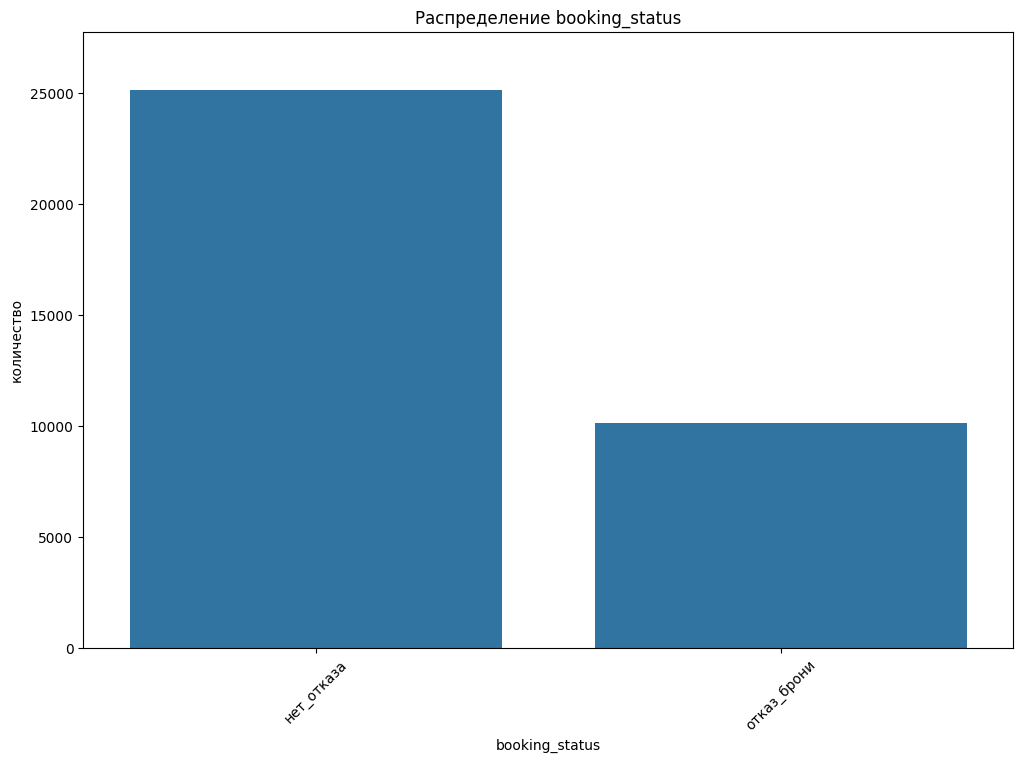

In [20]:
plot_count_bars(df_hotel_bookings, target_col)

In [21]:
df_hotel_bookings[target_col].value_counts() / len(df_hotel_bookings[target_col]) * 100

booking_status
нет_отказа     71.240203
отказ_брони    28.759797
Name: count, dtype: float64

Анализ:
- классы внутри таргета распределеные неравномерно 
- Дисбаланс 71/29%

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Нашли дисбаланс.</font>

#### Категориальные признаки

In [22]:
# исключение технических признаков id 
no_analyse_col_feats = ['booking_id', 'booking_date']
cat_cols_feat = [col for col in cat_cols_feat if col not in no_analyse_col_feats]
cat_cols_feat

['sales_channel', 'meal_plan', 'room_type']

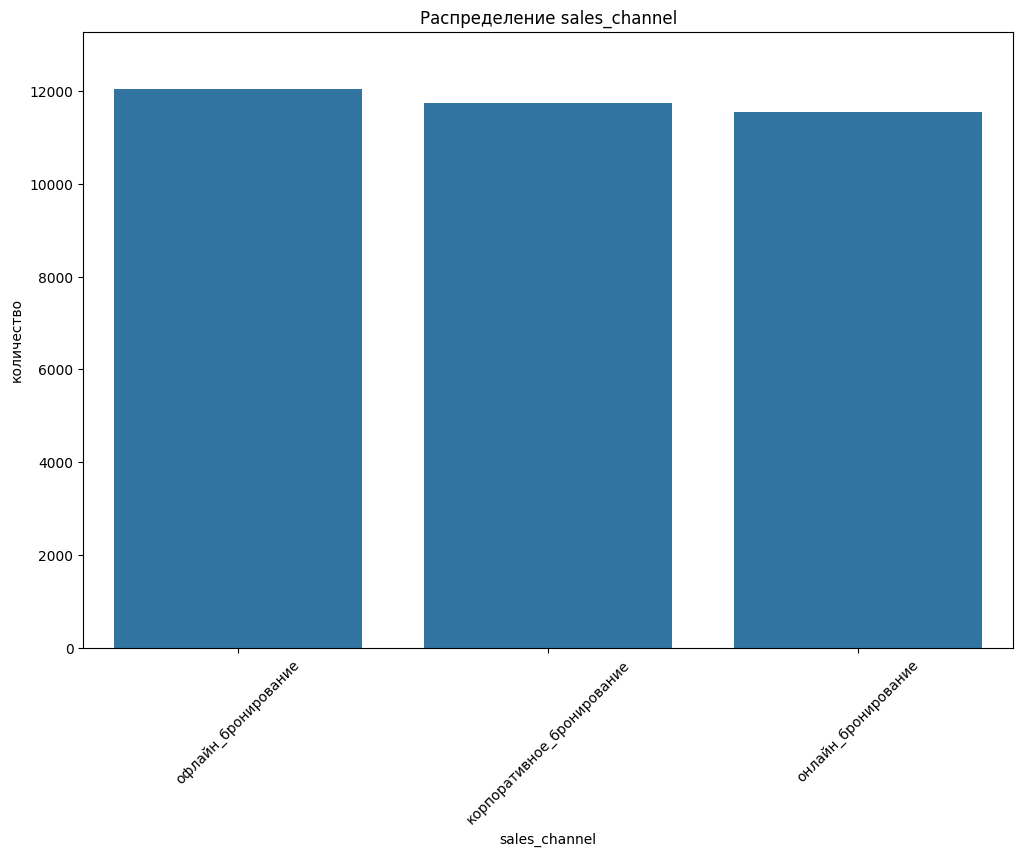

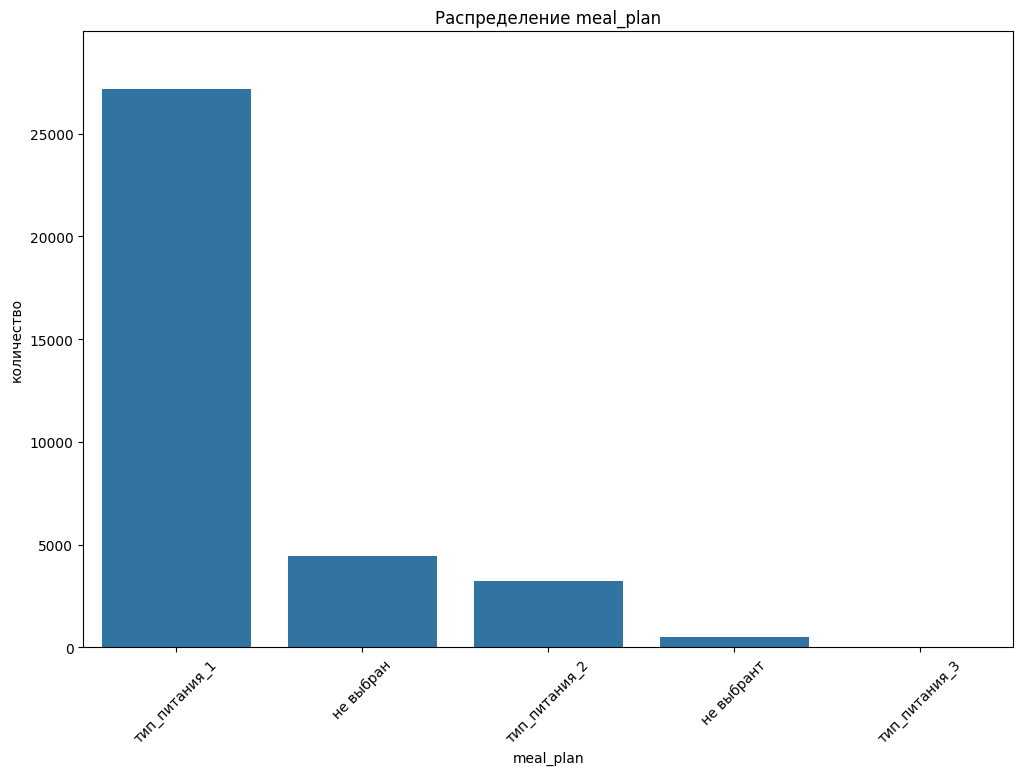

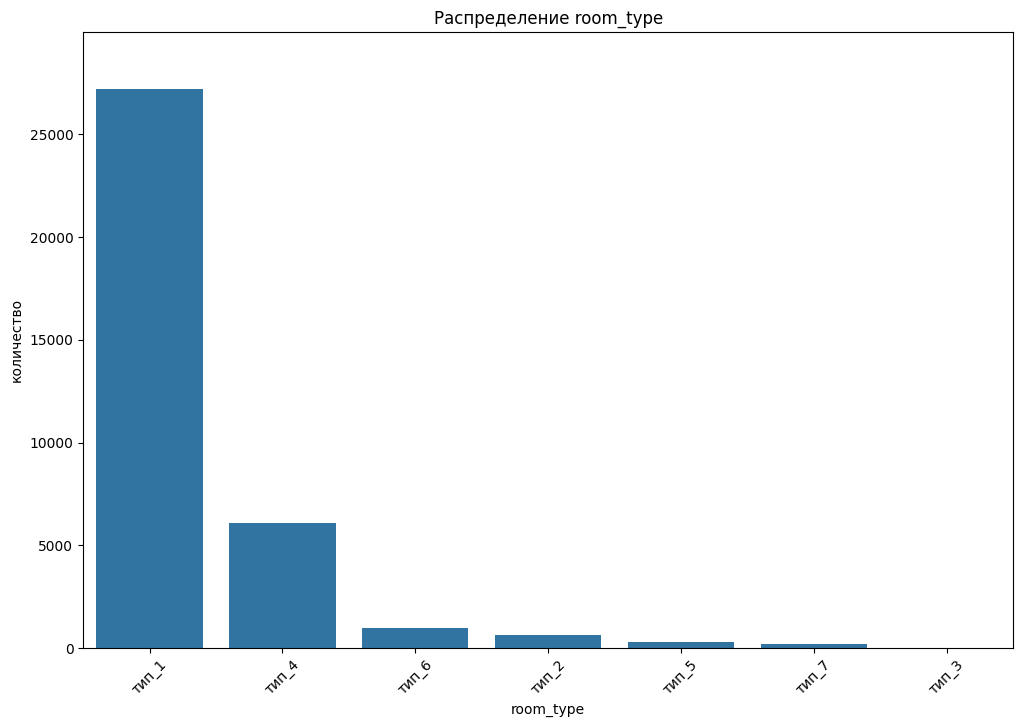

In [23]:
for name in cat_cols_feat:
    plot_count_bars(df=df_hotel_bookings, col_name=name)

Анализ:
- sales_channel: по способу оформления брони распределение равномерное
- meal_plan: 
    - По типу питания существенно лидирует 1 тип. 
    - Присутствует категория с опечаткой в названии. Стоит объединить `не выбран` и `не выбрант` в один признак. Он будет второй по популярности
    - 2ой тип в 9 раз уступает по популярности 1ому
    - 3 тип крайне малочисленный - всего 7шт, в то время как 1ого типа около 27к

- room_type: 
    - существенно преобладает тип_1 - 27к
    - на втором месте тип_4 с 6к
    - остальные менее 1к

#### Количественные признаки 

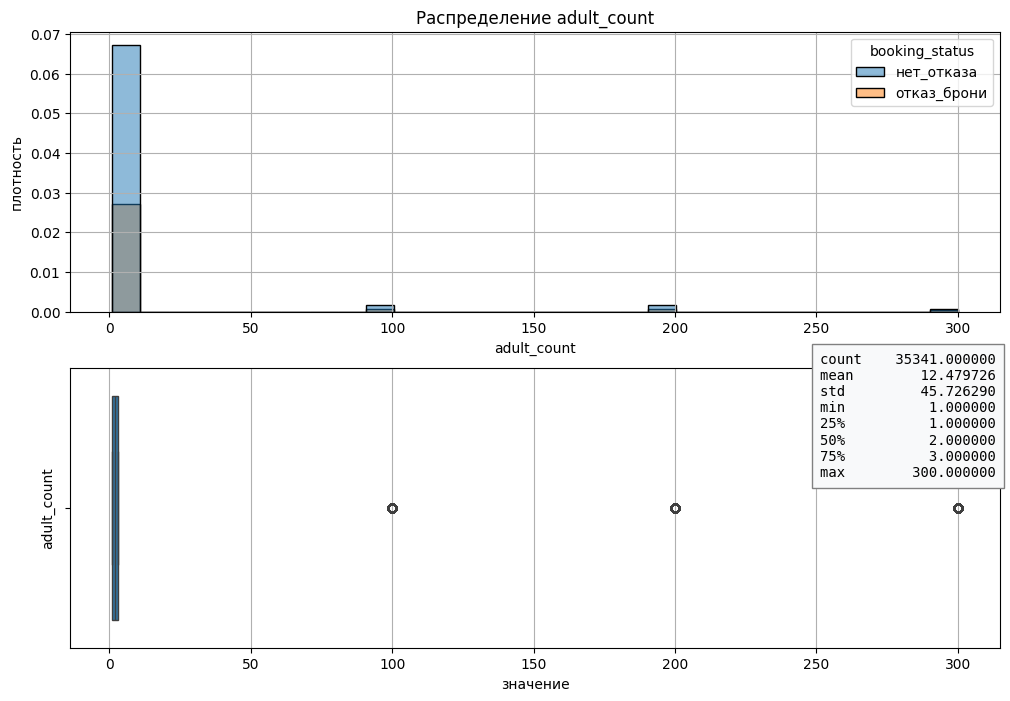

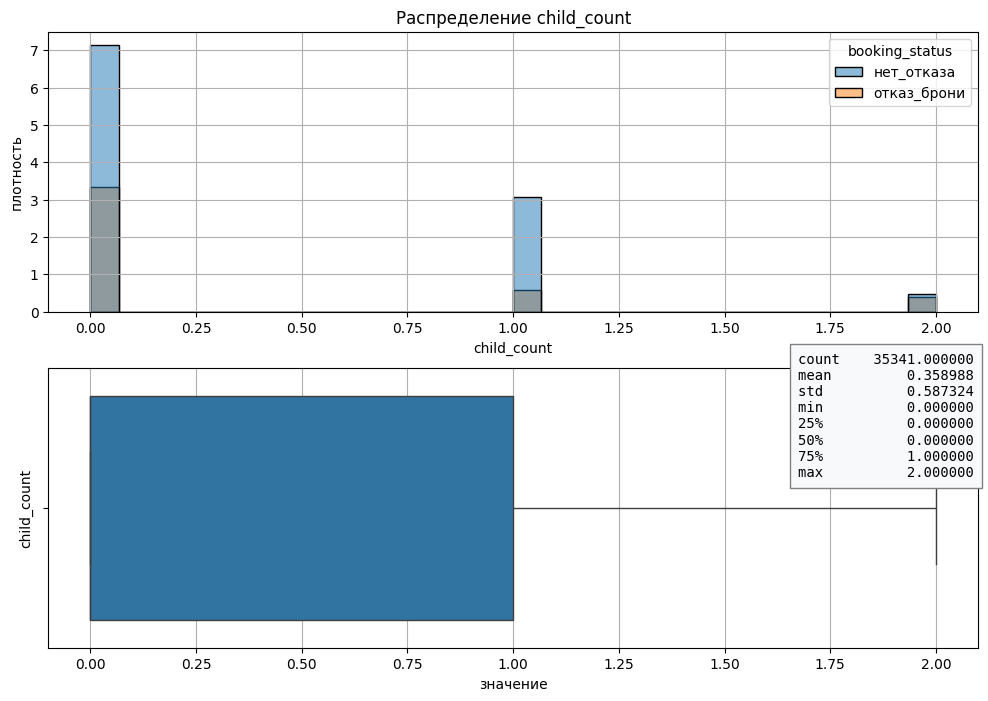

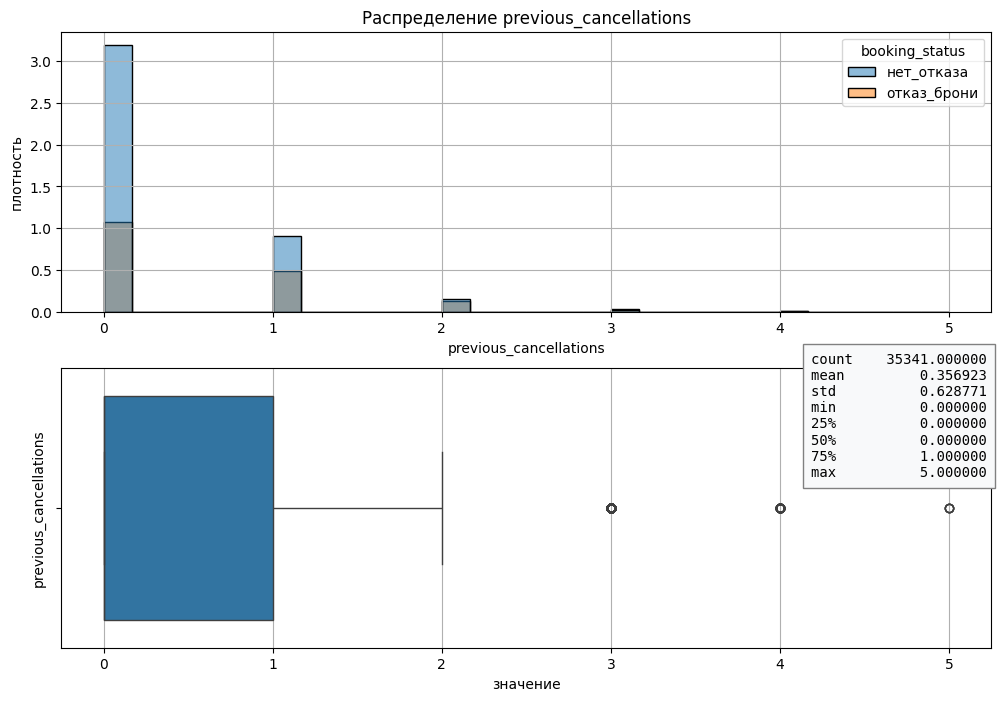

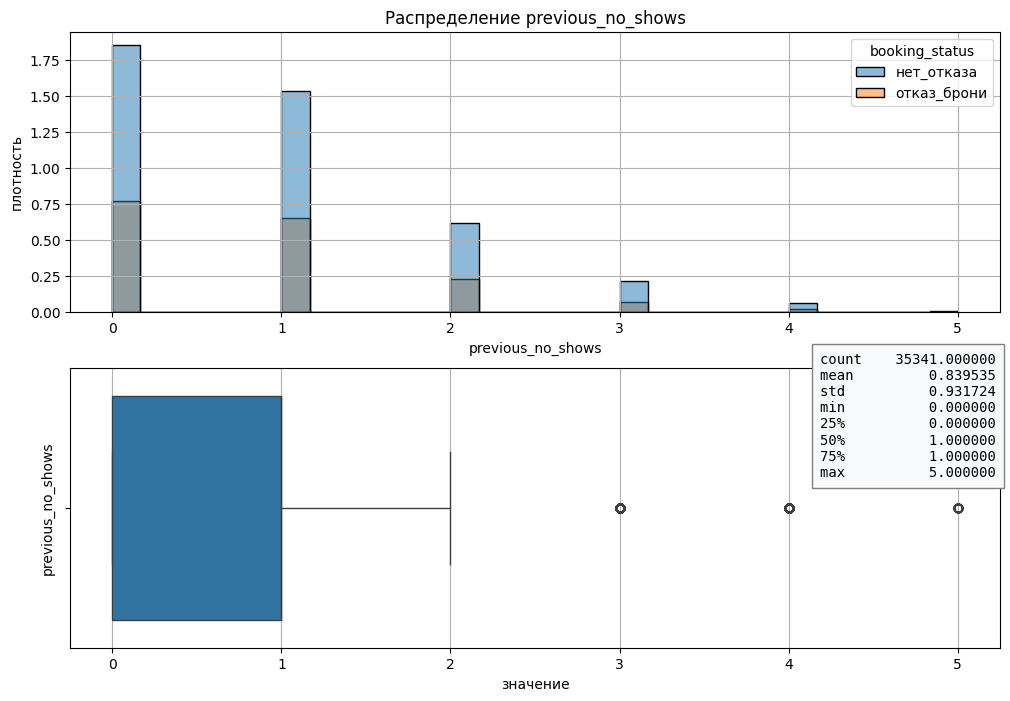

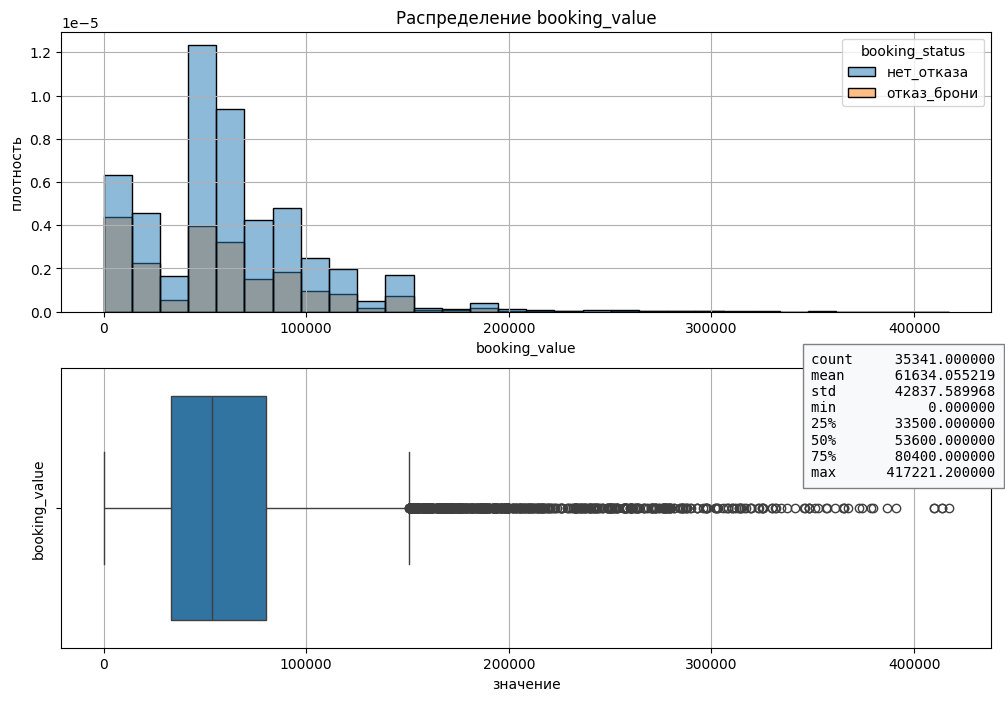

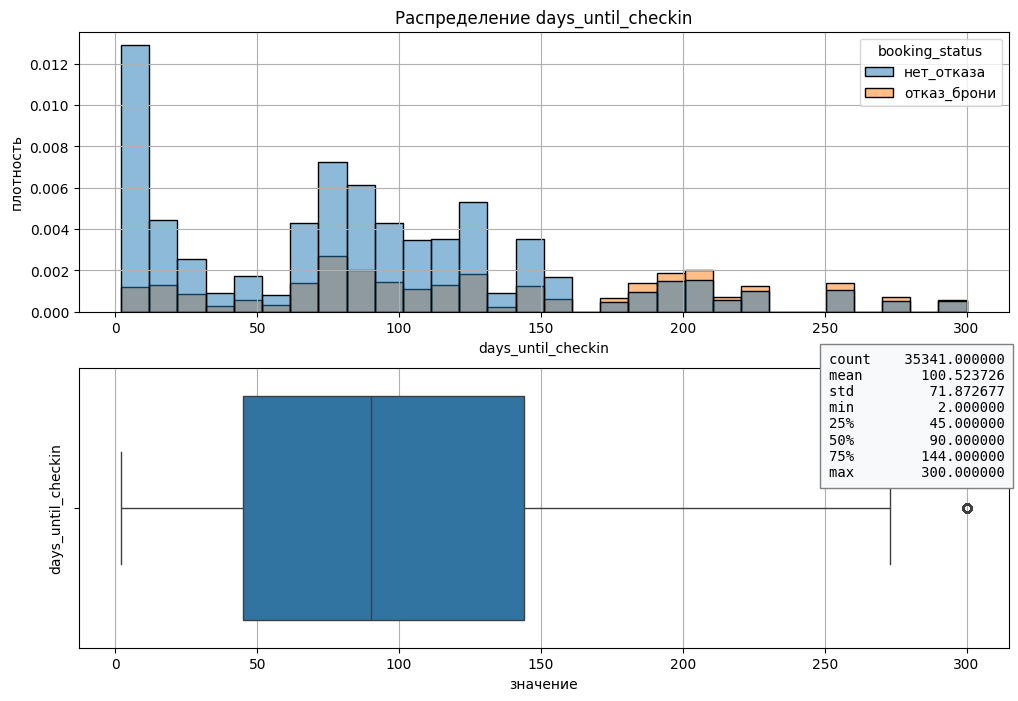

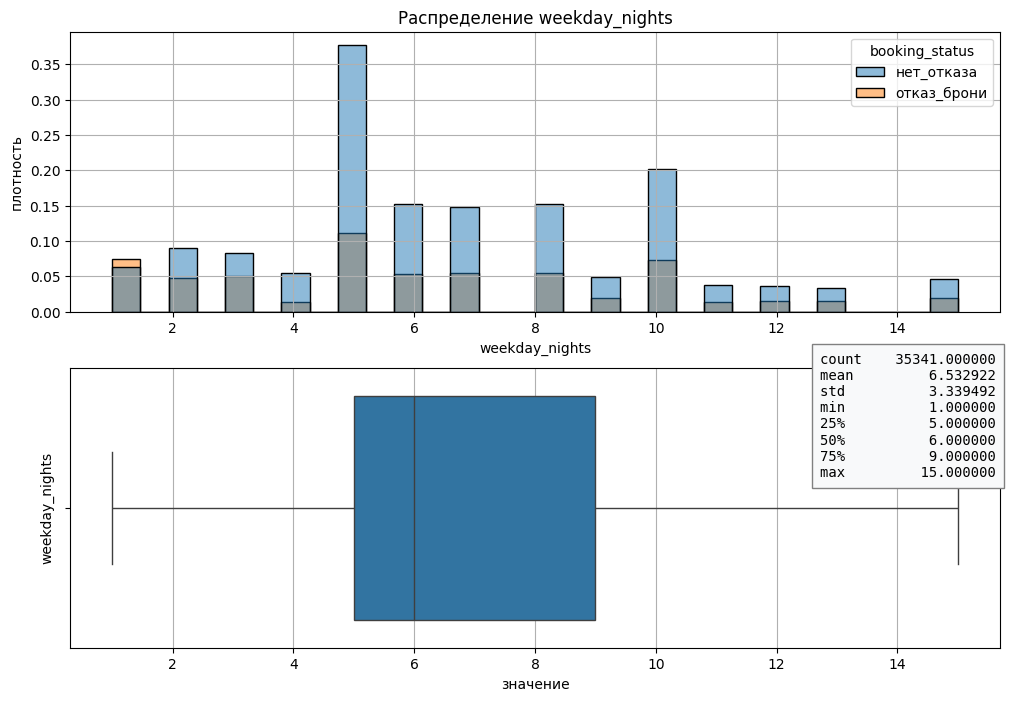

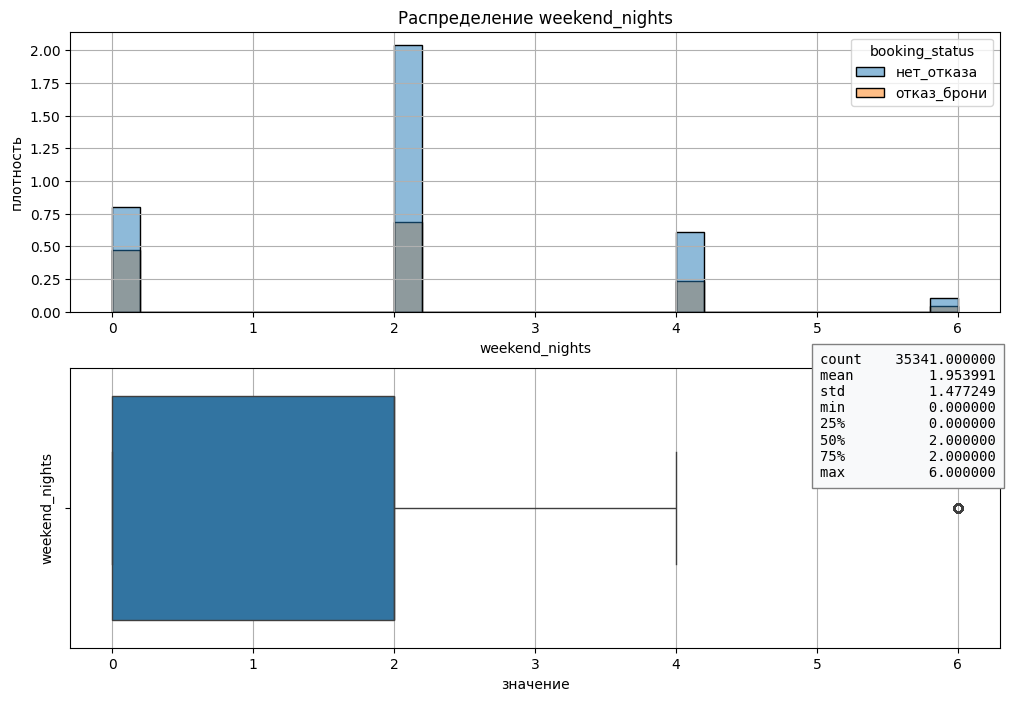

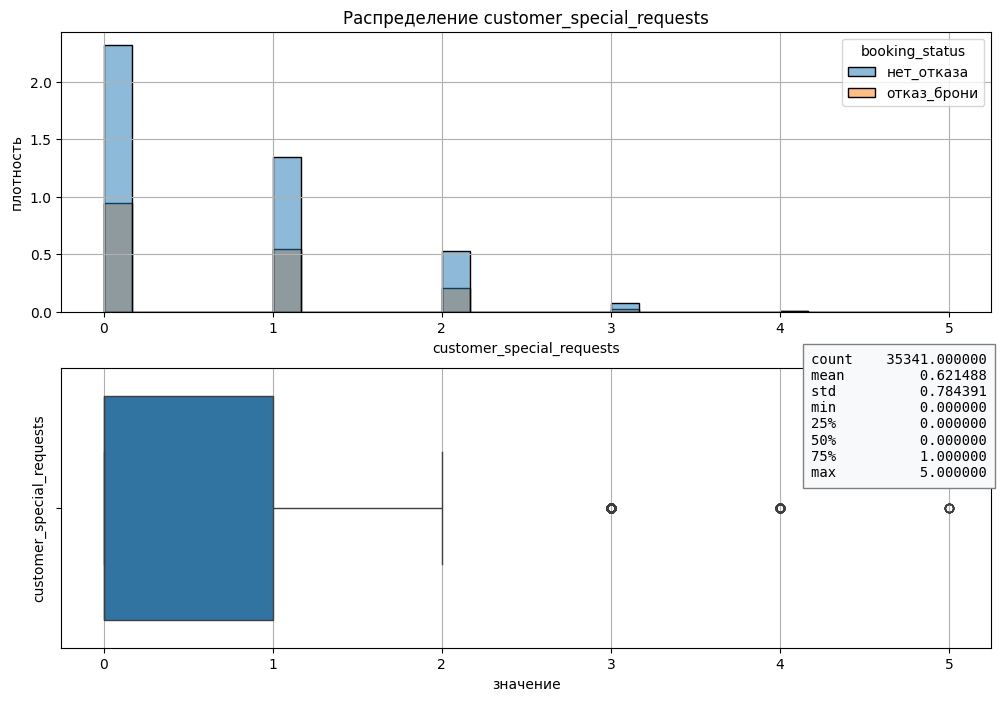

In [24]:
for name in num_cols_feat:
    plot_hist_box(df=df_hotel_bookings, feature_name=name, hue=target_col)

Анализ:
- adult_count: в основном 1-3 взрослых в номерах. Значения 100,200,300 скорее всего являются ошибочными. Необходимо провести корректировку.
- child_count: более 50% заселений без детей, с 1-2 детьми заселяются гораздо реже. С 2мя детьми доля отказов существенно выше, чем в других случаях
- previous_cancellations: экспоненциально убывает количество предыдущих отмен броней. При этом доля отмен растет - чем больше в прошлом было отмен, тем вероятней сейчас тоже отменит
- previous_no_shows: экспоненциально убывает количество неподтвержденных броней. 
- booking_value: итоговая стоимость бронирования сосредоточена в интервале 0-200к. Значения с нулевой стоимостью, предположительно, являются ошибками записи данных и требуют дополнительного исследования. Присутствуют малочисленные выбросы +400к
- days_until_checkin: в основном бронируют номера незадолго до заселения (пик по частоте 2-10 дней). При этом доля отмен выше среди длительных сроков броней.
- weekend_nights: наиболее часто 5 дней. Наиболее высокая доля отказов при 1 ночи
- weekday_nights: в основном 2 дня. Явных зависимостей с таргетом не видно
- customer_special_requests: кол-во просьб убывает экспоненциально.  Явных зависимостей с таргетом не прослеживается

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Обрати внимание на группы в adult_count.\
Здесь явная ошибка записи. Нужно убрать нули у аномальных значений. 300 → 3</font>

</span><br><span style="color: purple; font-weight: bold">Я предположил, что это корпоративные брони. Но, действительно, похоже больше на опечатки, требующие корректировок. </span>

**корректировка ошибок записи для adult_count**

- значения 100, 200, 300 в adult_count являются ошибочными. Предлагается провести корректировку, убрав лишние нули

In [25]:

df_hotel_bookings['adult_count'] = df_hotel_bookings['adult_count'].replace({100: 1, 200: 2, 300: 3})

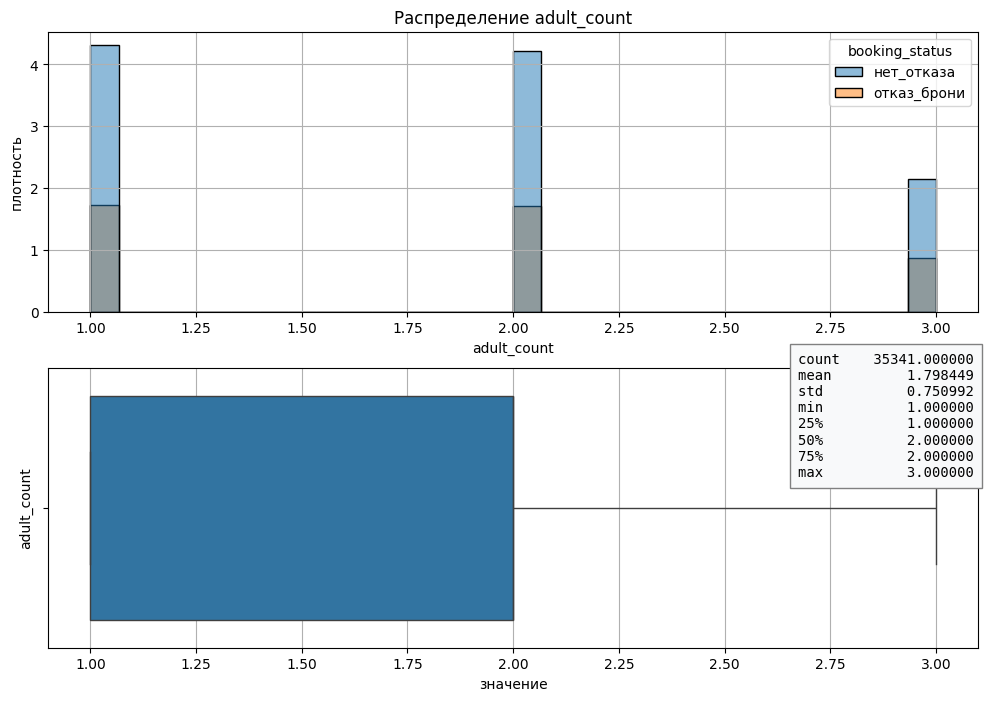

In [26]:
plot_hist_box(df=df_hotel_bookings, feature_name='adult_count', hue=target_col)

Анализ:
- распределение по значению adult_count после исправления ошибок записи  не имеет особенностей. Чаще всего заселяются 1-2 человека. Доля отмен не меняется

**Корректировка значений в booking_value**
- нулевая стоимость является ошибкой записи. Предлагается провести корректировку таких значений

In [27]:
# доля нулевых значений
zero_book_value_mask = df_hotel_bookings['booking_value'] == 0

zero_book_value_mask.mean() * 100


np.float64(4.020825669901814)

Доля ошибочных данных мала: 4%. Принято решение исключить такие строки из анализа

In [28]:
df_hotel_bookings = df_hotel_bookings[~zero_book_value_mask]

### Таблица **hotel_reviews**

In [29]:
df_hotel_reviews.columns

Index(['customer_id', 'booking_id', 'review_date', 'stay_rating',
       'review_text'],
      dtype='object')

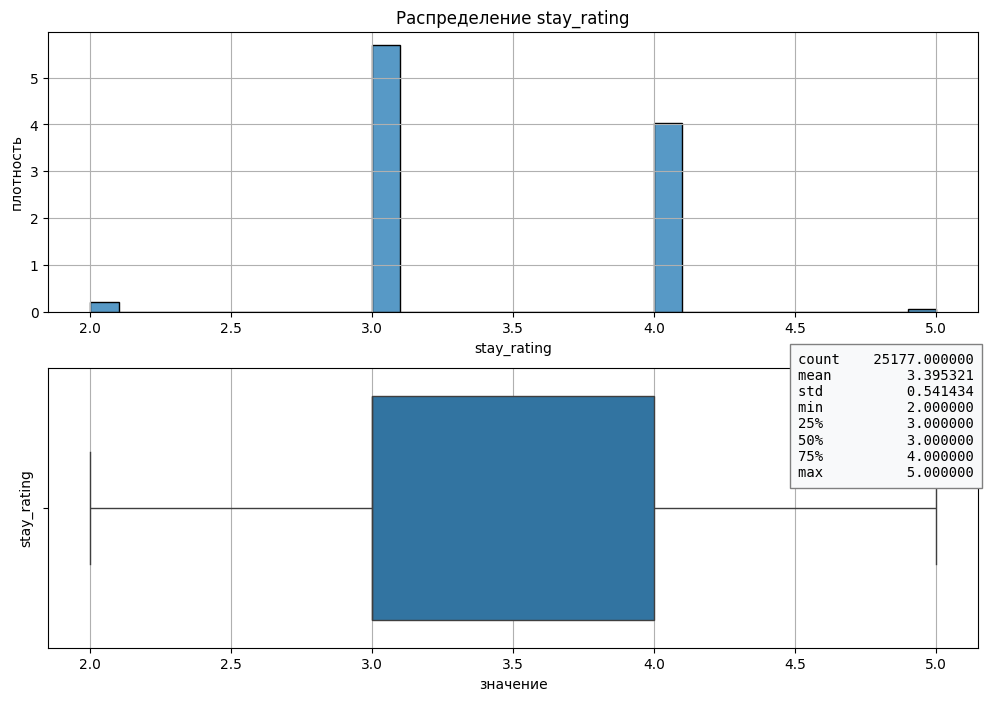

In [30]:
plot_hist_box(df=df_hotel_reviews, feature_name='stay_rating')

In [31]:
# доля уникальных отзывов
df_hotel_reviews['review_text'].nunique() / len(df_hotel_reviews) * 100

56.2140048456925

In [32]:
df_hotel_reviews['review_text'].value_counts()

review_text
Отличный отель! хорошие виды из окон.                                                                                                                                  42
Отличный отель! достаточное освещение.                                                                                                                                 40
Отличный отель! приятная музыка в лобби.                                                                                                                               38
Отличный отель! качественные продукты на завтрак.                                                                                                                      37
Отличный отель! вежливый персонал.                                                                                                                                     37
                                                                                                                                          

Анализ:
- stay_rating: основные оценки 3,4. 2,5 - редко ставят. 
- review_text: уникальных отзывов около 56%. Большое количество отднотипных отзывов существенно упростит векторизацию и формирование новых признаков.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Есть много нулевых значений стоимости.
 Причём и у тех кто отменил бронь, и у тех, кто не отменял.
 В данных не должно так быть. Стоимость номера всегда есть. Поэтому, считаем,
 что данные строки по бронированию не качественные. И лучше от них сразу избавиться.</font>

</span><br><span style="color: purple; font-weight: bold">Внес правки: строки с нулевой стоимостью брони исключены из таблицы </span>

### Объединение таблиц

In [33]:
# чистка от явных дублей
init_len_df_hotel_bookings = len(df_hotel_bookings)

df_hotel_bookings.drop_duplicates(inplace=True)

print('Потери при устранении дублей (%): ', (init_len_df_hotel_bookings - len(df_hotel_bookings)) / init_len_df_hotel_bookings * 100 )

Потери при устранении дублей (%):  13.018867924528301


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

In [34]:
# Преобразование типов
df_hotel_bookings['booking_date'] = pd.to_datetime(df_hotel_bookings['booking_date'])
df_hotel_reviews['review_date'] = pd.to_datetime(df_hotel_reviews['review_date'])

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [35]:
df_hotel_reviews.head()

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


In [36]:
df_hotel_bookings.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [37]:
df_hotel_bookings_client_ids = df_hotel_bookings.merge(df_hotel_reviews[['customer_id', 'booking_id']], how='left', on='booking_id')
df_hotel_bookings_client_ids

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id
0,INN00000,2020-07-08,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0,C0001
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1,C0001
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0,C0001
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0,C0002
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1,C0003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32654,INN30727,2020-03-05,корпоративное_бронирование,1,0,False,0,0,отказ_брони,89000.0,210,8,2,не выбран,False,тип_1,0,NaN
32655,INN30728,2020-04-08,корпоративное_бронирование,1,0,False,1,0,нет_отказа,13400.0,7,2,0,тип_питания_1,False,тип_1,2,C16473
32656,INN30729,2017-01-31,корпоративное_бронирование,1,2,False,0,0,нет_отказа,6700.0,50,1,0,тип_питания_2,False,тип_1,1,C16474
32657,INN30730,2019-10-11,офлайн_бронирование,1,1,False,0,0,нет_отказа,53600.0,15,6,2,тип_питания_1,False,тип_1,1,C16475


In [41]:
df_total = pd.merge_asof(
    df_hotel_bookings_client_ids.sort_values(by='booking_date'), 
    df_hotel_reviews.drop(columns='booking_id').sort_values(by='review_date'), 
    left_on='booking_date',
    right_on='review_date',
    direction='backward',
    by='customer_id',
    allow_exact_matches=True
)
get_base_df_info('df_total', df_total)

Общая информация о датафрейме df_total


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,...,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67000.0,...,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
1,INN00177,2017-01-01,онлайн_бронирование,2,0,False,0,0,отказ_брони,67000.0,...,8,2,тип_питания_2,False,тип_1,0,NaN,NaT,NaN,NaN
2,INN22445,2017-01-01,офлайн_бронирование,2,0,False,0,0,нет_отказа,71200.0,...,6,2,не выбран,False,тип_1,0,C12041,NaT,NaN,NaN
3,INN11824,2017-01-01,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,...,1,0,тип_питания_1,False,тип_4,1,C6306,NaT,NaN,NaN
4,INN20018,2017-01-01,онлайн_бронирование,3,0,True,1,1,отказ_брони,46900.0,...,5,2,тип_питания_1,False,тип_1,2,NaN,NaT,NaN,NaN


,Метрика,Значение
0,Строк,32659.00
1,Колонок,21.00
2,"Явных дубликатов, %",9.66
3,Категориальных колонок,7.00
4,Числовых колонок,10.00


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
review_text,object,23424,71.72,5933
review_date,datetime64[ns],23424,71.72,2042
stay_rating,float64,23424,71.72,5
customer_id,object,8492,26.00,13082
booking_id,object,0,0.00,29504
booking_date,datetime64[ns],0,0.00,2440
booking_value,float64,0,0.00,1765
days_until_checkin,int64,0,0.00,79
weekday_nights,int64,0,0.00,14
room_type,object,0,0.00,7


Типы колонок


,Категориальные колонки,Числовые колонки
0,booking_id,adult_count
1,sales_channel,child_count
2,booking_status,previous_cancellations
3,meal_plan,previous_no_shows
4,room_type,booking_value
5,customer_id,days_until_checkin
6,review_text,weekday_nights
7,NaN,weekend_nights
8,NaN,customer_special_requests
9,NaN,stay_rating


--------------------------------------------------


In [55]:
# проверка правила присоединения
review_date_not_na = df_total['review_date'].notna()

(df_total[review_date_not_na]['booking_date'] < df_total[review_date_not_na]['review_date']).sum()

np.int64(0)

Нет строк, нарушающих правило присоединения отзывов к данным о брони.

Следовательно, формирование итоговой таблицы корректно.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>
`shift(-1)` берёт следующую бронь:\
shift(-1) сдвигает вперёд — для каждого отзыва берётся booking_id следующей брони клиента. Затем мерж привязывает этот отзыв к следующей брони.\
Что происходит: отзыв написан после проживания → привязать его к следующей брони как "предыдущий опыт". Логика интересная, но реализация некорректная по нескольким причинам:

- Не проверяется что review_date < booking_date следующей брони — отзыв может быть написан после даты следующей брони
- Если у клиента только одна бронь — shift(-1) даст NaN
- Мерж по future_booking_id — ненадёжная связь
</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'>В библиотеке pandas для этого есть специальная мощная функция — pd.merge_asof. Она идеально подходит для сопоставления событий во времени.</font>

</span><br><span style="color: purple; font-weight: bold">Внес правки: использовал pd.merge_asof </span>

Итог:
- проведено преобразование типов данных к datetime в таблицах перед соединением, проведена сортировка по датам
- потери при устранении дублей в таблице hotel_bookings: 13%
- создана общая таблица с информацией о бронировании и отзывах клиентов
- исправлены ошибки в данных столбцов: booking_value и adults_count
- информация по отзывам присоединена по правилу: ближайший отзыв клиента с прошлой брони номера
- в итоговой таблице 71% записей о бронировании без отзывов и рейтингов. Это существенное количество. Пропуски оставляются как есть, модели бустинга умеют работать с пропусками из коробки

### Создание новых признаков

In [59]:
# сезонность в виде месяца планируемого заезда
df_total = df_total.sort_values(by='booking_id')
df_total['checkin_month'] = (df_total['booking_date'] + pd.to_timedelta(df_total['days_until_checkin'], unit='days')).dt.month

In [60]:
# лояльность клиента: кол-во предыдущих броней
df_total['prev_booking_count'] = df_total.sort_values('booking_date').groupby('customer_id')['booking_id'].cumcount()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Датафрейм должен быть отсортирован по `booking_date` перед вычислением .cumcount()</span>

</span><br><span style="color: purple; font-weight: bold">Добавил сортировку </span>

#### Формирование признака на основе текста отзыва

In [61]:
# Загрузка стоп-слов и пунктуации
nltk.download('stopwords')
nltk.download('punkt')
nltk.download("punkt_tab")
stop_words = set(stopwords.words('russian'))
punctuation = set(string.punctuation)

morph = pymorphy3.MorphAnalyzer()

def preprocess_text(text):

    words = word_tokenize(text.lower())
    lemmatized_words = [morph.parse(word)[0].normal_form for word in words]
    filtered_words = [
        word
        for word in lemmatized_words
        if word not in stop_words and word not in punctuation
    ]
    return " ".join(filtered_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Очистка сделана верно! Мы оставили только символы алфавита и привели к нижнему регистру!\
Убрали частые неинформативные слова!</font>

In [62]:
# инициализация векторизатора текста
tfidf_vectorizer = TfidfVectorizer()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Векторизатор нельзя обучать на всём корпусе текстов (до разделения на выборки)\
На данном этапе достаточно сконфигурировать TfidfVectorizer, а обучать внутри кросс-валидации.</font>

</span><br><span style="color: purple; font-weight: bold">Оставил только предобработку текста и инициализацию векторизатора </span>

In [63]:
def create_text_feature():
    df_total["clean_review"] = df_total[
        "review_text"
    ].fillna('').apply(preprocess_text)

    tfidf_matrix = tfidf_vectorizer.fit_transform(
        df_total["clean_review"]
    )
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # суммарный TF-IDF каждого слова по всем отзывам
    tfidf_scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()

    top_n = 30
    top_indices = tfidf_scores.argsort()[::-1][:top_n]

    top_tfidf_words = pd.DataFrame({
        "word": feature_names[top_indices],
        "tfidf_score": tfidf_scores[top_indices]
    })

    top_words = set(top_tfidf_words["word"])

    # Список для хранения одного главного слова отзыва
    top_single_words = []

    # Проходим по строкам матрицы TF-IDF
    for i in range(tfidf_matrix.shape[0]):
        row = tfidf_matrix[i].toarray().ravel()

        # Проверяем, есть ли вообще слова в этом отзыве (максимальный вес > 0)
        if row.max() > 0:
            # Находим индекс слова с самым большим весом TF-IDF
            top_word_idx = row.argmax()
            # Извлекаем само слово
            top_word = feature_names[top_word_idx]
        else:
            # Если отзыв пустой или состоял только из стоп-слов
            top_word = "другое"

        top_single_words.append(top_word)

    df_total["main_review_word"] = pd.Series(
        top_single_words, dtype="category"
    )
    df_total["main_review_word"] = df_total["main_review_word"].where(
        df_total["main_review_word"].isin(top_words),
        "другое"
    ).astype("category")

Итог:
- сформировано 2 признака на основе информации об отзывах и предыдущих бронях клиентов: 
    - checkin_month - отражает сезонность, 
    - prev_booking_count - отражает лояльность, 
- признаки, основанные на текстах отзывов создаются в пайплайне обучения 

### Предобработка по результатам ИАД

In [65]:
# чистка от неинформативных признаков
df_total = df_total.drop(columns=["review_text", 'booking_id', 'booking_date', 'customer_id', 'review_date'])

In [66]:
# правка опечаток
df_total['meal_plan'] = df_total['meal_plan'].replace('не выбрант', "не выбран")
df_total['meal_plan'].unique()

array(['тип_питания_2', 'тип_питания_1', 'не выбран', 'тип_питания_3'],
      dtype=object)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Отлично, поправили опечатку!</font>

In [67]:
dupl_part = df_total.duplicated().sum() / len(df_total) * 100

df_total = df_total.drop_duplicates()
print('Потери при очистке дублей (%): ', dupl_part)

Потери при очистке дублей (%):  0.12247772436388131


In [68]:
cat_cols, num_cols = get_cat_num_cols(df_total)

In [69]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32619 entries, 24526 to 10548
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sales_channel              32619 non-null  object 
 1   adult_count                32619 non-null  int64  
 2   child_count                32619 non-null  int64  
 3   returning_customer         32619 non-null  bool   
 4   previous_cancellations     32619 non-null  int64  
 5   previous_no_shows          32619 non-null  int64  
 6   booking_status             32619 non-null  object 
 7   booking_value              32619 non-null  float64
 8   days_until_checkin         32619 non-null  int64  
 9   weekday_nights             32619 non-null  int64  
 10  weekend_nights             32619 non-null  int64  
 11  meal_plan                  32619 non-null  object 
 12  parking_included           32619 non-null  bool   
 13  room_type                  32619 non-null  obje

In [70]:
for col in cat_cols:
	# приведение всех категориальных признаков к pd.categorical
	df_total[col] = df_total[col].astype('category')

In [71]:
# приведение таргета к бинарному виду
df_total["booking_status"] = (
    df_total["booking_status"]
    .map({"отказ_брони": 1, "нет_отказа": 0})
    .astype("int8")
)
df_total["booking_status"].unique()

array([0, 1], dtype=int8)

In [72]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32619 entries, 24526 to 10548
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   sales_channel              32619 non-null  category
 1   adult_count                32619 non-null  int64   
 2   child_count                32619 non-null  int64   
 3   returning_customer         32619 non-null  bool    
 4   previous_cancellations     32619 non-null  int64   
 5   previous_no_shows          32619 non-null  int64   
 6   booking_status             32619 non-null  int8    
 7   booking_value              32619 non-null  float64 
 8   days_until_checkin         32619 non-null  int64   
 9   weekday_nights             32619 non-null  int64   
 10  weekend_nights             32619 non-null  int64   
 11  meal_plan                  32619 non-null  category
 12  parking_included           32619 non-null  bool    
 13  room_type                  32619

### Корреляционный анализ

In [75]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреляций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [76]:
corr_matrix = get_corr_matrix(
    data=df_total, 
    feat_cols=num_cols_feat + cat_cols_feat + [target_col], 
    num_cols=num_cols_feat + [target_col]
)

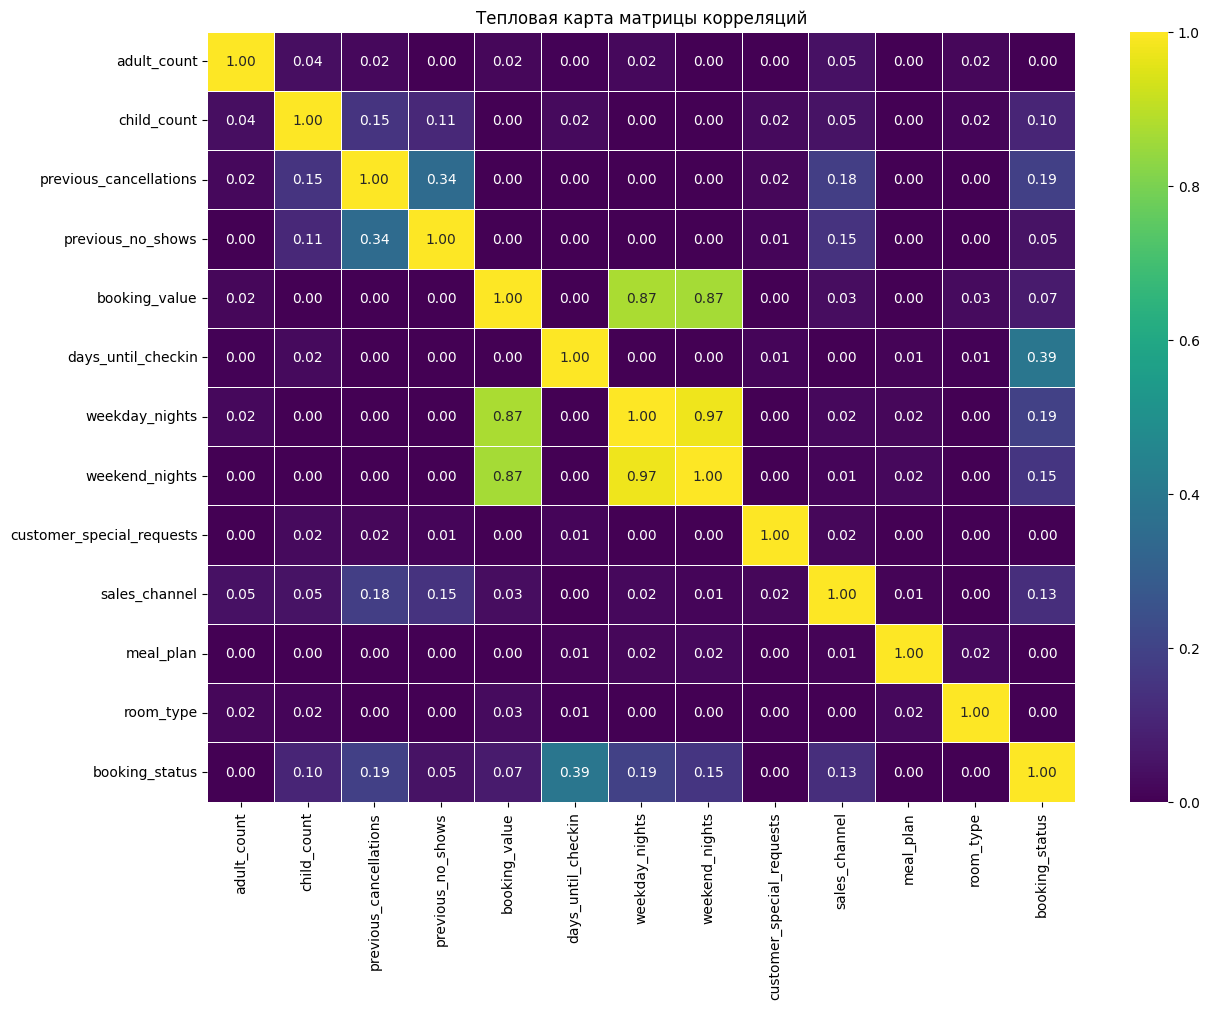

In [77]:
plot_corr_matrix(corr_matrix)

Анализ:
- признаки weekday_nights и weekend_nights сильно скоррелированы друг с другом: корреляция выше 0.95. Ожидаемо, поскольку люди подряд бронируют отель на будни и выходные дни. Чтобы бороться с мультиколлинеарностью при обучении стоит добавлять коэффициенты регуляризации.
- стоимость брони выскоко скоррелировано с кол-вом ночей (длительностью пребывания). Ожидаемо, поскольку чем дольше клиент пребывает, тем дороже бронь
- с таргетом больше всего скоррелирован признак days_until_checkin. Можно предположить, что чем больше времени до брони, тем вероятней отмена.

### Анализ итоговой таблицы

In [78]:
get_base_df_info('df_total', df_total)

Общая информация о датафрейме df_total


,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,checkin_month,prev_booking_count
24526,корпоративное_бронирование,3,0,False,0,0,0,6700.0,21,1,0,тип_питания_2,False,тип_1,0,NaN,7,0.0
30458,корпоративное_бронирование,3,0,True,0,1,0,62300.0,15,5,2,тип_питания_2,False,тип_1,1,3.0,10,1.0
32141,корпоративное_бронирование,3,0,True,0,2,0,46900.0,96,5,2,тип_питания_1,False,тип_1,0,3.0,2,2.0
550,онлайн_бронирование,2,0,False,0,0,0,53600.0,150,6,2,тип_питания_1,False,тип_1,0,NaN,7,0.0
13726,корпоративное_бронирование,1,0,True,1,1,0,46900.0,96,5,2,тип_питания_1,False,тип_1,1,NaN,6,0.0


,Метрика,Значение
0,Строк,32619.0
1,Колонок,18.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,3.0
4,Числовых колонок,13.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
stay_rating,float64,23384,71.69,5
prev_booking_count,float64,8485,26.01,9
booking_value,float64,0,0.00,1765
days_until_checkin,int64,0,0.00,79
weekday_nights,int64,0,0.00,14
checkin_month,int32,0,0.00,12
room_type,category,0,0.00,7
previous_cancellations,int64,0,0.00,6
previous_no_shows,int64,0,0.00,6
customer_special_requests,int64,0,0.00,6


Типы колонок


,Категориальные колонки,Числовые колонки
0,sales_channel,adult_count
1,meal_plan,child_count
2,room_type,previous_cancellations
3,NaN,previous_no_shows
4,NaN,booking_status
5,NaN,booking_value
6,NaN,days_until_checkin
7,NaN,weekday_nights
8,NaN,weekend_nights
9,NaN,customer_special_requests


--------------------------------------------------


Анализ:
- итоговая таблица состоит из данных о бронировании и информации об отзывах клиентов
- дублей нет. Потери при очистке менее 0.1%
- исправлены ошибки в данных столбцов: booking_value и adults_count
- информация по отзывам присоединена по правилу: ближайший отзыв клиента с прошлой брони номера
- пропуски есть в признаках prev_booking_count и stay_rating: 71%. Вызвано это тем, что не у всех клиентов есть история броней и не все оставляют отзывы. Процент существенный, оставляем как есть. Модели бустинга умеют работать с пропусками.
- текстовые данные предобработаны: приведены к нижнему регистру и очищены от стоп-слов
- таблица содержит новые признаки checkin_month - отражает сезонность, prev_booking_count - отражает лояльность клиентов.
- таргет "booking_status" преобразован к бинарному флагу: 1 - отмена брони, 0 - бронь подтверждена

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> Нужно провести анализ корреляций, как стандартный шаг ИАД.</font>

## Этап 2: моделирование

### Обучение и оптимизация модели

### Разделение на выборки


In [79]:
X = df_total.drop(columns='booking_status')
y = pd.Series(df_total['booking_status'], name='target')
display(X.shape, y.shape)

(32619, 17)

(32619,)

In [80]:
cat_cols, num_cols = get_cat_num_cols(df=X)
cat_cols

['sales_channel', 'meal_plan', 'room_type']

In [81]:
# train 80% и validate 20%
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [82]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    shuffle=True,
    random_state=RANDOM_SEED
)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Для разделения данных на выборки, нужно отсортировать данные по времени ('booking_date'), а затем разделить без перемешивания, что бы тестовая выборка была позже всех.</font>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ⚠️\
<font color='darkorange'>Нам нужны три выборки: обучающая, калибровочная и тестовая. `X_val` нам не нужна. В проекте требуется кросс-валидация.</font>

In [54]:
AVG_REV = 64_500
COST_FP = 7_000
LOST_REV = AVG_REV
PER_REBOOKING = 45_000


def inc_rev_metric(y_true, y_pred):
    """
    Финансовый результат при заданной стратегии предсказаний.

    Если y_pred состоит только из нулей, функция возвращает результат до внедрения
    модели: состоявшиеся брони дают AvgRev, отмены дают LostRev.
    Если y_pred содержит прогнозы модели, функция возвращает результат после
    внедрения: TP можно повторно продать, FP дают стоимость ошибки, FN остаются
    потерянной выручкой.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    ir = (
        (tp * PER_REBOOKING)
        + (tn * AVG_REV)
        - (fp * COST_FP)
        - (fn * LOST_REV)
    )
    return ir


def rel_inc_rev_metric(y_true, y_pred_prev, y_pred_new):
    prev_ir = inc_rev_metric(y_true, y_pred_prev)
    new_ir = inc_rev_metric(y_true, y_pred_new)

    if prev_ir == 0:
        return np.nan
    return (new_ir - prev_ir) / prev_ir * 100


def evaluate_model(y_true, y_pred):
    # макро-усреднение лучше работает для несбалансирвоанных данных 
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'inc_metric': inc_rev_metric(y_true, y_pred)
    }
    return metrics


def get_result_df(model_names: list[str], metric_dicts: list[dict]):
    # Преобразование результатов в датафрейм
    df_results = pd.DataFrame({
        name: {
            k: v for k, v in metric_dict.items()
        } for name, metric_dict in zip(model_names, metric_dicts)
    })
    return df_results

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Расчёт incremental revenue (IR) верный.</font>

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'>Константы можно вынести в начало модуля</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">
Усреднение `average='macro'` применяется к мультиклассовой классификации и в нашем случае нужно `average='binary'`\
При macro-подходе sklearn считает метрику отдельно для класса 0 и класса 1, а затем берет среднее арифметическое. Если твоя модель будет идеально предсказывать частый класс (заезды), но полностью провалит редкий целевой класс (отмены), метрика macro все равно покажет вполне приличный результат (около 45-50%) за счет доминирующего класса.</span>

### Обучение базовой модели CatBoostClassifier

In [55]:
cbc_model_base = CatBoostClassifier(
    random_state=RANDOM_SEED,
    loss_function="Logloss",
    eval_metric="Logloss",
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=False,
    n_estimators=1500
)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Верно, что применяешь нативную кодировку моделей.</font>

In [56]:
cbc_model_base.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_cols
)

CatBoostClassifier(early_stopping_rounds=50, eval_metric='Logloss', loss_function='Logloss', n_estimators=1500, random_state=42, use_best_model=True, verbose=False)

In [57]:
y_pred_val_cbc_model_base = cbc_model_base.predict(X_val)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Нужна кросс-валидация со специальным Сплитером - [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) с test_size=2000 . </span>
> 2. Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

In [58]:
#  отчет по всем метрикам
report = classification_report(y_val, y_pred_val_cbc_model_base)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4642
           1       0.76      0.66      0.71      1786

    accuracy                           0.85      6428
   macro avg       0.82      0.79      0.80      6428
weighted avg       0.84      0.85      0.85      6428



Анализ:
- в целом хороший baseline: f1-score для классов более 0.7
- базовая модель существенно точнее предсказывает более часто встречающийся класс (precision выше на 20%)

Рекомендация:
- необходимо провести оптимизацию параметров, чтобы улучшить качество предсказания

### Обучение базовой модели XGBClassifier

In [59]:
xgb_model_base = XGBClassifier(
    enable_categorical=True,
    n_estimators=1500,
    objective="binary:logistic",
    random_state=RANDOM_SEED,
    eval_metric="logloss", 
    n_jobs=-1, 
    early_stopping_rounds=50       
)


In [60]:
xgb_model_base.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [61]:
y_pred_val_cxgb_model_base = xgb_model_base.predict(X_val)

In [62]:
#  отчет по всем метрикам
report = classification_report(y_val, y_pred_val_cxgb_model_base)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4642
           1       0.75      0.67      0.71      1786

    accuracy                           0.85      6428
   macro avg       0.82      0.79      0.80      6428
weighted avg       0.84      0.85      0.84      6428



Анализ:
- модель уловила основные закономерности и не переобучилась 
- схожая ситуация метрикам предсказания классов: более многочисленный класс предсказыается точнее по всем показателям (precision, recall, f1-score)

Рекомендация:
- оптимизация гиперпараметров

In [63]:
base_model_results = []
base_val_preds = [y_pred_val_cbc_model_base, y_pred_val_cxgb_model_base]

for pred in base_val_preds:
    result = evaluate_model(y_true=y_val, y_pred=pred)
    base_model_results.append(result)

In [64]:
base_model_results_df = get_result_df(
    model_names=['cbc_model_base', 'cxgb_model_base'],
    metric_dicts=base_model_results
)
base_model_results_df

,cbc_model_base,cxgb_model_base
accuracy,8.490977e-01,8.472309e-01
precision_macro,8.195290e-01,8.157874e-01
recall_macro,7.921734e-01,7.922588e-01
f1_macro,8.038998e-01,8.025422e-01
inc_metric,2.876240e+08,2.870700e+08


Анализ:
- результаты базовых моделей близки по ключевым метрикам

### Оптимизация гиперпараметров

In [65]:
def objective_xgb(trial):
    """
    Функция-цель для оптимизации параметров xgb
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.1, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    threshold = trial.suggest_float("threshold", 0.05, 0.95)

    model = XGBClassifier(
        **params, 
        enable_categorical=True,
        n_estimators=1500,
        objective="binary:logistic",
        random_state=RANDOM_SEED,
        eval_metric="logloss", 
        n_jobs=-1, 
        early_stopping_rounds=50
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )
    
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_proba >= threshold).astype(int)

    score = inc_rev_metric(y_val, y_val_pred)

    return score

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Здесь то же нужна кросс-валидация. </span>

In [66]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

In [67]:
# запуск оптимизации
study_xgb = optuna.create_study(direction="maximize", sampler=sampler) 
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True) 

[I 2026-07-01 00:15:40,570] A new study created in memory with name: no-name-5c143f2c-56d6-4ddb-ae48-a4217e951c50


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-01 00:15:41,881] Trial 0 finished with value: 241011500.0 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'gamma': 0.7319939444914656, 'reg_lambda': 5.9865848459837805, 'reg_alpha': 1.5601864128641787, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'threshold': 0.8295585311974416}. Best is trial 0 with value: 241011500.0.
[I 2026-07-01 00:15:42,967] Trial 1 finished with value: 276369500.0 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 8, 'gamma': 0.020584504089957503, 'reg_lambda': 9.699098521920844, 'reg_alpha': 8.32442640967979, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'threshold': 0.21506405886809044}. Best is trial 1 with value: 276369500.0.
[I 2026-07-01 00:15:44,485] Trial 2 finished with value: 290863000.0 and parameters: {'learning_rate': 0.02014847788415866, 'max_depth': 7, 'gamma': 0.43194502432266557, 'reg_lambda': 2.9122914090681276, 'reg_alpha': 6.11852895110

In [68]:
xgb_best_params = study_xgb.best_params.copy()
xgb_best_threshold = xgb_best_params.pop("threshold") # бизнес-оптимальный порог

xgb_best_opt = XGBClassifier(
    **xgb_best_params, 
    enable_categorical=True,
    n_estimators=1500,
    objective="binary:logistic",
    random_state=RANDOM_SEED,
    eval_metric="logloss", 
    n_jobs=-1, 
    early_stopping_rounds=50
)

In [69]:
xgb_best_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
y_val_proba_xgb_best_opt = xgb_best_opt.predict_proba(X_val)[:, 1]
y_val_pred_xgb_best_opt = (y_val_proba_xgb_best_opt >= xgb_best_threshold).astype(int)
xgb_best_opt_metrics = evaluate_model(
    y_true=y_val, y_pred=y_val_pred_xgb_best_opt
)
xgb_best_opt_metrics

{'accuracy': 0.839607965152458,
 'precision_macro': 0.7983573026837255,
 'recall_macro': 0.8252188137618791,
 'f1_macro': 0.8092321294909992,
 'inc_metric': np.int64(292002500)}

### Оптимизация модели  CatBoost


In [70]:
def objective_catboost(trial):
    """
    Функция-цель для оптимизации параметров catboost
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1., 10.),
    }
    threshold = trial.suggest_float("threshold", 0.05, 0.95)

    model = CatBoostClassifier(
        **params, 
        random_state=RANDOM_SEED,
        loss_function="Logloss",
        eval_metric="Logloss",
        early_stopping_rounds=50,
        use_best_model=True,
        verbose=False,
        n_estimators=1500
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols,
    )

    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_proba >= threshold).astype(int)

    score = inc_rev_metric(y_val, y_val_pred)

    return score

In [71]:
# запуск оптимизации
study_cbc = optuna.create_study(direction="maximize", sampler=sampler) 
study_cbc.optimize(objective_catboost, n_trials=30, show_progress_bar=True) 

[I 2026-07-01 00:16:27,014] A new study created in memory with name: no-name-7d5333dc-15a7-470b-9ca1-066f1237f78a


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-01 00:16:27,777] Trial 0 finished with value: 252897000.0 and parameters: {'learning_rate': 0.18832519048593593, 'max_depth': 7, 'l2_leaf_reg': 3.9780822236738427, 'threshold': 0.10720251525742126}. Best is trial 0 with value: 252897000.0.
[I 2026-07-01 00:16:30,336] Trial 1 finished with value: 273715500.0 and parameters: {'learning_rate': 0.028797752657070342, 'max_depth': 5, 'l2_leaf_reg': 7.566455605042576, 'threshold': 0.6238017242196917}. Best is trial 1 with value: 273715500.0.
[I 2026-07-01 00:16:30,891] Trial 2 finished with value: 265366000.0 and parameters: {'learning_rate': 0.20441878352493792, 'max_depth': 6, 'l2_leaf_reg': 2.0763482134447155, 'threshold': 0.6919203085006954}. Best is trial 1 with value: 273715500.0.
[I 2026-07-01 00:16:31,776] Trial 3 finished with value: 286779500.0 and parameters: {'learning_rate': 0.13297554090738672, 'max_depth': 7, 'l2_leaf_reg': 7.938704619591049, 'threshold': 0.49441603672795165}. Best is trial 3 with value: 286779500.0.

In [72]:
catboost_best_params = study_cbc.best_params.copy()
catboost_best_threshold = catboost_best_params.pop("threshold", None)

catboost_best_opt = CatBoostClassifier(
    **catboost_best_params, 
    random_state=RANDOM_SEED,
    loss_function="Logloss",
    eval_metric="Logloss",
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=False,
    n_estimators=1500
)

In [73]:
catboost_best_opt.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_cols,
)
y_val_proba_catboost_best_opt = catboost_best_opt.predict_proba(X_val)[:, 1]
y_val_pred_catboost_best_opt = (y_val_proba_catboost_best_opt >= catboost_best_threshold).astype(int)
catboost_best_opt_metrics = evaluate_model(
    y_pred=y_val_pred_catboost_best_opt, y_true=y_val
)
catboost_best_opt_metrics

{'accuracy': 0.842874922215308,
 'precision_macro': 0.8022798055302172,
 'recall_macro': 0.8180074040372411,
 'f1_macro': 0.809335284302545,
 'inc_metric': np.int64(291414000)}

### Итоговая таблица

In [74]:
best_model_results = []
opt_val_preds = [y_val_pred_xgb_best_opt, y_val_pred_catboost_best_opt]

for pred in opt_val_preds:
    result = evaluate_model(y_true=y_val, y_pred=pred)
    best_model_results.append(result)

In [75]:
best_model_results_df = get_result_df(
    model_names=['cbc_model_best', 'cxgb_model_best'],
    metric_dicts=best_model_results
)
best_model_results_df

,cbc_model_best,cxgb_model_best
accuracy,8.396080e-01,8.428749e-01
precision_macro,7.983573e-01,8.022798e-01
recall_macro,8.252188e-01,8.180074e-01
f1_macro,8.092321e-01,8.093353e-01
inc_metric,2.920025e+08,2.914140e+08


In [76]:
results = pd.concat(
    [base_model_results_df.T, best_model_results_df.T]
).sort_values(by='inc_metric', ascending=False)
results

,accuracy,precision_macro,recall_macro,f1_macro,inc_metric
cbc_model_best,0.839608,0.798357,0.825219,0.809232,292002500.0
cxgb_model_best,0.842875,0.802280,0.818007,0.809335,291414000.0
cbc_model_base,0.849098,0.819529,0.792173,0.803900,287624000.0
cxgb_model_base,0.847231,0.815787,0.792259,0.802542,287070000.0


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения.</font>

Итог:
- оптимизация гиперпараметров позволила улучшить ключевой финансовый показатель моделей inc_metric 
- recall_macro и f1_macro существенно просели: модель точнее определяет отмены броней (повысился precision), при этом доля предсказанных отмен из всех существенно просела (recall_macro). Общая точность accuracy снизилась. 
- Объяснить снижение accuracy, recall_macro, f1_macro можно тем, что оптимизация шла по финансовому показателю. Точное предсказание отмены дает возможность передать номер другому клиенту и не потерять прибыль. 
- лучшее качество по ключевой метрике inc_metric показывает оптимизированная модель XGBClassifier

### Калибровка модели и пересчёт результатов

In [77]:
def plot_calibration_curve(y_true, y_probas: list, names: list[str], n_bins=10, title='Calibration Curve'):
    """Построение калибровочной кривой"""
    
    for y_proba, name in zip(y_probas, names):
        prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)

        plt.plot(prob_pred, prob_true, marker='o', label=name)
    
    plt.plot([0, 1], [0, 1], linestyle='--', label='Идеальная калибровка')
    plt.xlabel('Предсказанная вероятность')
    plt.ylabel('Истинная вероятность')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [78]:
def get_calib_metrics(y_calib, model_probabilities, sort_by=['brier_score']):
    """Резельтат калибровки"""
    calibration_metrics = []
    for model_name, y_proba in model_probabilities.items():
        calibration_metrics.append({
            'model': model_name,
            'brier_score': brier_score_loss(y_calib, y_proba),
        })

    return (
        pd.DataFrame(calibration_metrics)
        .sort_values(by=sort_by, ascending=True)
        .reset_index(drop=True)
    )

In [79]:
def get_calibrated_model(fitted_model, X_calib, y_calib, method='isotonic'):
    """Откалибровать уже обученную модель без повторного обучения estimator."""
    calibrated_model = CalibratedClassifierCV(
        estimator=fitted_model,
        method=method,
        n_jobs=-1,
        cv='prefit'
    )
    calibrated_model.fit(X_calib, y_calib)

    return calibrated_model

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Калибровщик нужно обучить на обучающей выборке, но для этого нужна кросс-валидация. с tscv.\
`X_calib` для оценки калибровки.</font>
>  Калибровка лучшей модели. Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

In [80]:
if xgb_best_opt_metrics['inc_metric'] >= catboost_best_opt_metrics['inc_metric']:
    best_model_name = 'xgb_best_opt'
    best_model_threshold = xgb_best_threshold
    best_n_estimators = getattr(xgb_best_opt, 'best_iteration', None)
    best_n_estimators = best_n_estimators + 1 if best_n_estimators is not None else 1500

    best_model = XGBClassifier(
        **xgb_best_params,
        enable_categorical=True,
        n_estimators=best_n_estimators,
        objective='binary:logistic',
        random_state=RANDOM_SEED,
        eval_metric='logloss',
        n_jobs=-1,
    )
else:
    best_model_name = 'catboost_best_opt'
    best_model_threshold = catboost_best_threshold
    best_n_estimators = catboost_best_opt.get_best_iteration()
    best_n_estimators = best_n_estimators + 1 if best_n_estimators is not None else 1500

    best_model = CatBoostClassifier(
        **catboost_best_params,
        random_state=RANDOM_SEED,
        loss_function='Logloss',
        eval_metric='Logloss',
        verbose=False,
        n_estimators=best_n_estimators,
        cat_features=tuple(cat_cols),
    )

best_model_name, best_model_threshold, best_n_estimators

('xgb_best_opt', 0.3803150109565958, 637)

In [81]:
best_model_full = best_model.fit(X_train, y_train)
best_model_calibrated = get_calibrated_model(
    fitted_model=best_model_full,
    X_calib=X_val,
    y_calib=y_val,
    method='isotonic',
)

y_val_proba_best_model = best_model_full.predict_proba(X_val)[:, 1]
y_val_proba_best_model_calibrated = best_model_calibrated.predict_proba(X_val)[:, 1]

calibration_probabilities = {
    f'{best_model_name}_before_calibration': y_val_proba_best_model,
    f'{best_model_name}_after_calibration': y_val_proba_best_model_calibrated,
}

calibration_results_df = get_calib_metrics(y_val, calibration_probabilities)
display(calibration_results_df)


,model,brier_score
0,xgb_best_opt_after_calibration,0.100181
1,xgb_best_opt_before_calibration,0.101676


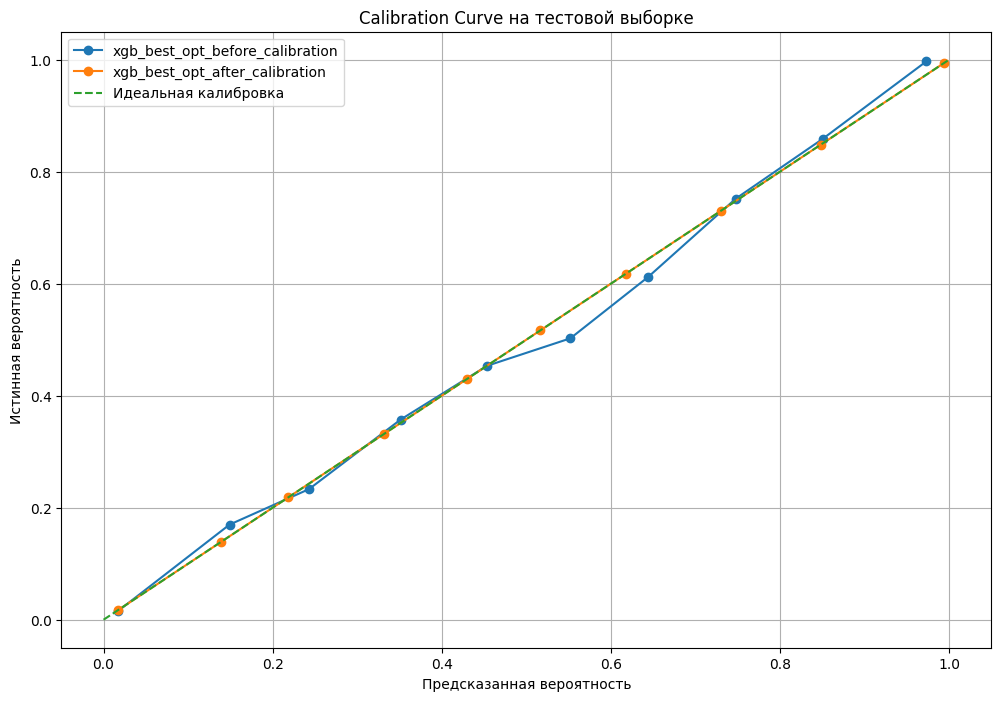

,xgb_best_opt_before_calibration,xgb_best_opt_after_calibration
accuracy,8.396080e-01,8.366521e-01
precision_macro,7.983573e-01,7.956898e-01
recall_macro,8.252188e-01,8.295453e-01
f1_macro,8.092321e-01,8.083014e-01
inc_metric,2.920025e+08,2.920500e+08


Brier score:  
до калибровки: 0.1017 
после 0.1002.


In [82]:
plot_calibration_curve(
    y_val,
    list(calibration_probabilities.values()),
    list(calibration_probabilities.keys()),
    title='Calibration Curve на тестовой выборке',
)

y_val_pred_best_model = (y_val_proba_best_model >= best_model_threshold).astype(int)
y_val_pred_best_model_calibrated = (
    y_val_proba_best_model_calibrated >= best_model_threshold
).astype(int)

calibration_business_results_df = get_result_df(
    model_names=[
        f'{best_model_name}_before_calibration',
        f'{best_model_name}_after_calibration',
    ],
    metric_dicts=[
        evaluate_model(y_val, y_val_pred_best_model),
        evaluate_model(y_val, y_val_pred_best_model_calibrated),
    ],
)
display(calibration_business_results_df)

brier_before = brier_score_loss(y_val, y_val_proba_best_model)
brier_after = brier_score_loss(y_val, y_val_proba_best_model_calibrated)

if brier_after < brier_before:
    print(
        f'Brier score:  \n'
        f'до калибровки: {brier_before:.4f} \n'
        f'после {brier_after:.4f}.'
    )


Анализ:
- модель еще до калибровки показывает хорошее качество по Brier Score. 
То есть после обучения она уже хорошо откалибрована. 
Объясняется это тем, что logloss выступает в качестве функции потерь и метрикой итоговой оценки модели для отбора лучшей при обучении. Logloss автоматически калибрует модель.
- этап калибровки позволил несущественно улучшить Brier score

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

In [83]:
y_val_proba_best_model_calibrated = best_model_calibrated.predict_proba(X_val)[:, 1]

threshold_candidates = np.unique(
    np.r_[
        np.linspace(0.01, 0.99, 99),
    ]
)

threshold_results = []
for threshold in threshold_candidates:
    y_val_pred_threshold = (
        y_val_proba_best_model_calibrated >= threshold
    ).astype(int)
    threshold_results.append({
        'threshold': threshold,
        'inc_metric': inc_rev_metric(y_val, y_val_pred_threshold),
        'predicted_cancel_share': y_val_pred_threshold.mean(),
    })

threshold_results_df = pd.DataFrame(threshold_results)
best_threshold_row = threshold_results_df.loc[
    threshold_results_df['inc_metric'].idxmax()
]

best_model_calibrated_threshold = best_threshold_row['threshold']
best_model_calibrated_val_pred = (
    y_val_proba_best_model_calibrated >= best_model_calibrated_threshold
).astype(int)
best_model_calibrated_threshold_metrics = evaluate_model(
    y_val,
    best_model_calibrated_val_pred,
)

display(
    threshold_results_df
    .sort_values('inc_metric', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
best_model_calibrated_threshold_metrics

,threshold,inc_metric,predicted_cancel_share
0,0.41,292179000,0.322340
1,0.40,292179000,0.322340
2,0.39,292179000,0.322340
3,0.42,292179000,0.322340
4,0.34,292050000,0.337586
5,0.35,292050000,0.337586
6,0.36,292050000,0.337586
7,0.37,292050000,0.337586
8,0.38,292050000,0.337586
9,0.33,292016500,0.338052


{'accuracy': 0.8400746733042938,
 'precision_macro': 0.7988725886453159,
 'recall_macro': 0.8253697073267932,
 'f1_macro': 0.8096465420401584,
 'inc_metric': np.int64(292179000)}

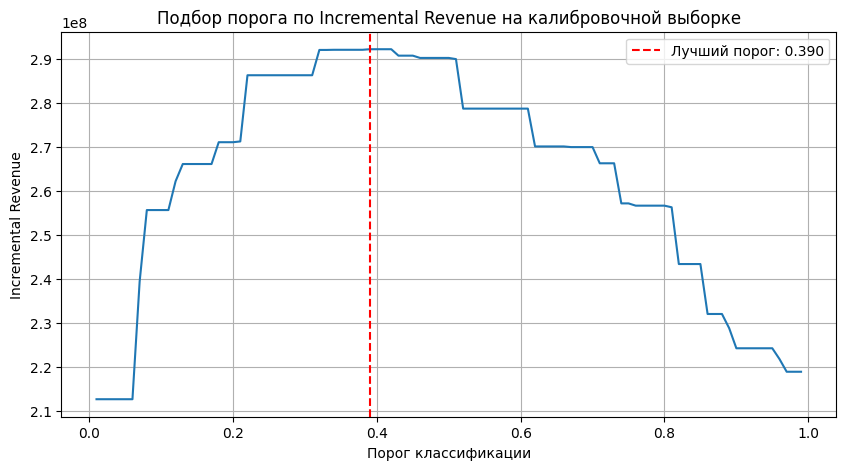

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['inc_metric'],
)
plt.axvline(
    best_model_calibrated_threshold,
    color='red',
    linestyle='--',
    label=f'Лучший порог: {best_model_calibrated_threshold:.3f}',
)
plt.xlabel('Порог классификации')
plt.ylabel('Incremental Revenue')
plt.title('Подбор порога по Incremental Revenue на калибровочной выборке')
plt.legend()
plt.grid()
plt.show()

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [85]:
old_threshold_val_pred = (
    y_val_proba_best_model_calibrated >= best_model_threshold
).astype(int)

old_threshold_ir = inc_rev_metric(y_val, old_threshold_val_pred)
new_threshold_ir = best_model_calibrated_threshold_metrics['inc_metric']
threshold_ir_delta = new_threshold_ir - old_threshold_ir

threshold_comparison_df = pd.DataFrame([
    {
        'threshold_type': 'previous_business_threshold',
        'threshold': best_model_threshold,
        'inc_metric': old_threshold_ir,
        'predicted_cancel_share': old_threshold_val_pred.mean(),
    },
    {
        'threshold_type': 'calibrated_best_threshold',
        'threshold': best_model_calibrated_threshold,
        'inc_metric': new_threshold_ir,
        'predicted_cancel_share': best_model_calibrated_val_pred.mean(),
    },
])

display(threshold_comparison_df)

,threshold_type,threshold,inc_metric,predicted_cancel_share
0,previous_business_threshold,0.380315,292050000,0.337586
1,calibrated_best_threshold,0.390000,292179000,0.322340


Итог:
- подбор порога практически не улучшил inc_metric: изменение менее 0.2%
- новый порог можно рекомендовать к использованию при предсказании отмены брони

### Анализ матрицы классификаций

#### Подготовка предсказаний

In [86]:
y_val_proba_final = best_model_calibrated.predict_proba(X_val)[:, 1]
y_test_proba_final = best_model_calibrated.predict_proba(X_test)[:, 1]

y_val_pred_final = (y_val_proba_final >= best_model_calibrated_threshold).astype(int)
y_test_pred_final = (y_test_proba_final >= best_model_calibrated_threshold).astype(int)

final_threshold = best_model_calibrated_threshold
final_threshold

np.float64(0.39)

#### Матрицы ошибок

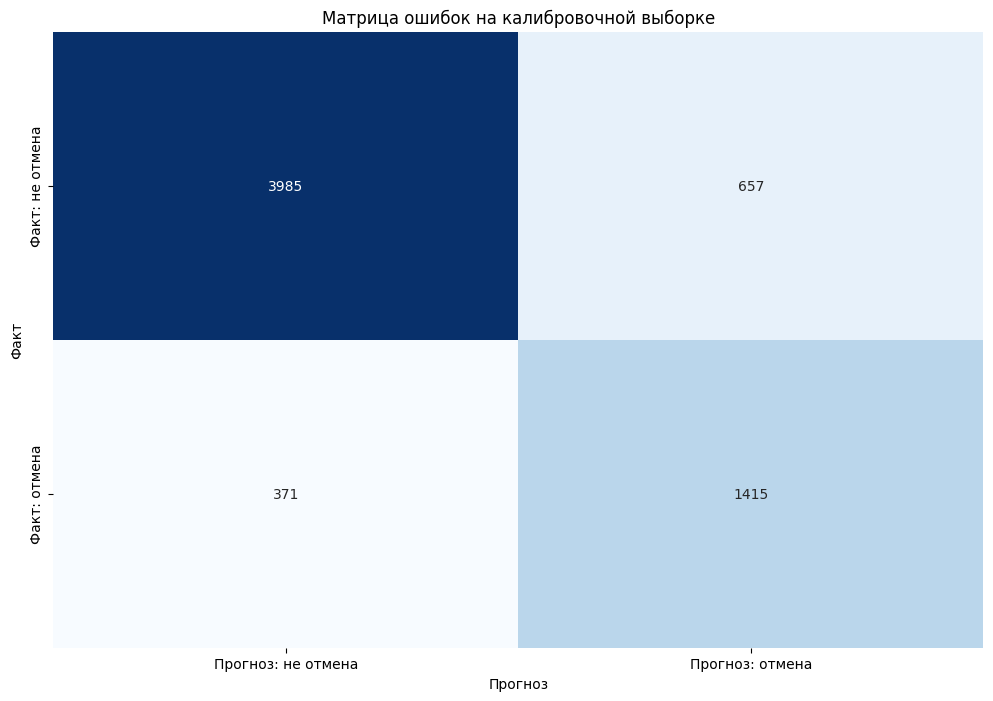

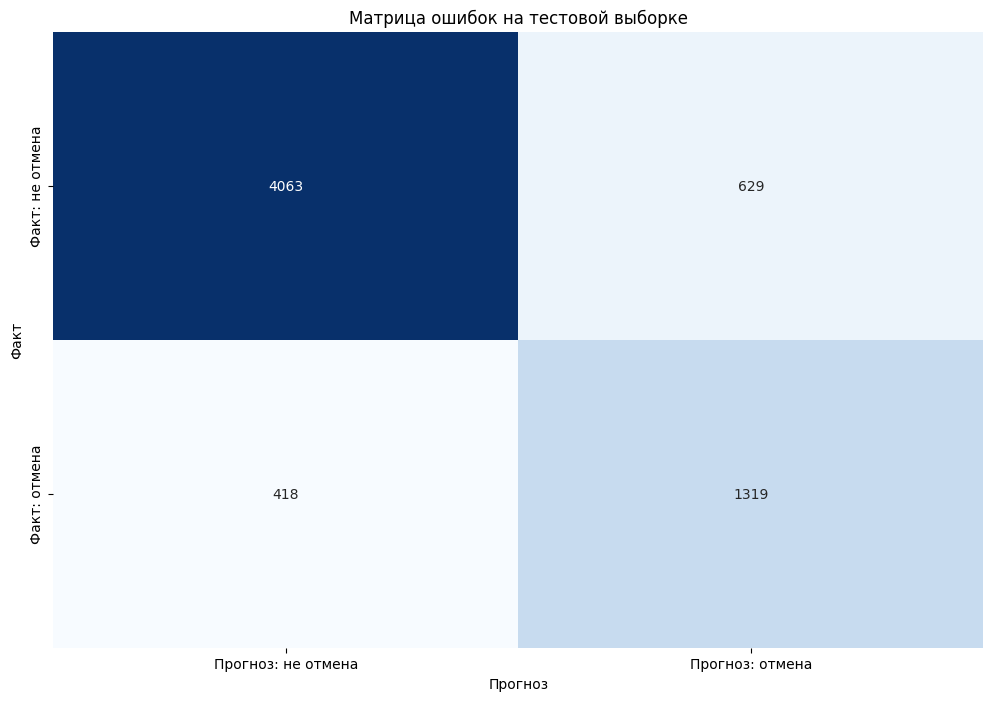

In [87]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm,
        index=['Факт: не отмена', 'Факт: отмена'],
        columns=['Прогноз: не отмена', 'Прогноз: отмена'],
    )

    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.ylabel('Факт')
    plt.xlabel('Прогноз')
    plt.show()


plot_confusion_matrix(
    y_val,
    y_val_pred_final,
    'Матрица ошибок на калибровочной выборке',
)

plot_confusion_matrix(
    y_test,
    y_test_pred_final,
    'Матрица ошибок на тестовой выборке',
)

Анализ: 
- матрица ошибок имеет схожий вид на калибрововчной и тестовой выборках, что свидетельствует о стабильности модели
- на представленных данных модель не допускает: прогноз нет отмены при реальной отмене. Объясняется это оптимизацией под финансовые показатели: самые дорогие ошибки сведены к минимуму
- при этом модель способствует овербукингу: часто прогнозирует отмену при фактическом ее отсутствии 

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отличная визуализация результата!</font>

#### IR и метрики стабильности

In [88]:
val_final_metrics = evaluate_model(y_val, y_val_pred_final)
test_final_metrics = evaluate_model(y_test, y_test_pred_final)

stability_results_df = get_result_df(
    model_names=['calibration', 'test'],
    metric_dicts=[val_final_metrics, test_final_metrics],
).T

stability_results_df['inc_metric_per_booking'] = [
    val_final_metrics['inc_metric'] / len(y_val),
    test_final_metrics['inc_metric'] / len(y_test),
]
stability_results_df['predicted_cancel_share'] = [
    y_val_pred_final.mean(),
    y_test_pred_final.mean(),
]
stability_results_df['true_cancel_share'] = [
    y_val.mean(),
    y_test.mean(),
]

display(stability_results_df)

confusion_summary_df = pd.DataFrame(
    [
        dict(
            dataset='calibration',
            **dict(zip(['tn', 'fp', 'fn', 'tp'], confusion_matrix(y_val, y_val_pred_final, labels=[0, 1]).ravel())),
        ),
        dict(
            dataset='test',
            **dict(zip(['tn', 'fp', 'fn', 'tp'], confusion_matrix(y_test, y_test_pred_final, labels=[0, 1]).ravel())),
        ),
    ]
)
display(confusion_summary_df)

,accuracy,precision_macro,recall_macro,f1_macro,inc_metric,inc_metric_per_booking,predicted_cancel_share,true_cancel_share
calibration,0.840075,0.798873,0.825370,0.809647,292179000.0,45454.107032,0.322340,0.277847
test,0.837144,0.791911,0.812649,0.800868,290054500.0,45116.581117,0.303002,0.270182


,dataset,tn,fp,fn,tp
0,calibration,3985,657,371,1415
1,test,4063,629,418,1319


#### Вывод о стабильности

In [89]:
val_ir_per_booking = stability_results_df.loc['calibration', 'inc_metric_per_booking']
test_ir_per_booking = stability_results_df.loc['test', 'inc_metric_per_booking']
ir_per_booking_delta = test_ir_per_booking - val_ir_per_booking

val_f1 = stability_results_df.loc['calibration', 'f1_macro']
test_f1 = stability_results_df.loc['test', 'f1_macro']
f1_delta = test_f1 - val_f1

val_pred_cancel_share = stability_results_df.loc['calibration', 'predicted_cancel_share']
test_pred_cancel_share = stability_results_df.loc['test', 'predicted_cancel_share']
pred_cancel_share_delta = test_pred_cancel_share - val_pred_cancel_share

print(f'Используемый порог классификации: {final_threshold:.4f}.')
print(
    f"IR на калибровочной выборке: {val_final_metrics['inc_metric']:,.0f}; "
    f"на тестовой выборке: {test_final_metrics['inc_metric']:,.0f}."
)
print(
    f'IR на одно бронирование изменился на {ir_per_booking_delta:,.2f}; '
    f'F1 macro изменился на {f1_delta:.4f}.'
)


print(f'Разница по F1 macro на train и test: {f1_delta}')

Используемый порог классификации: 0.3900.
IR на калибровочной выборке: 292,179,000; на тестовой выборке: 290,054,500.
IR на одно бронирование изменился на -337.53; F1 macro изменился на -0.0088.
Разница по F1 macro на train и test: -0.008778618198419519



Итог:
- Ключевая финансовая метрика показала существенный рост на тестовых данных, что говорит об отсутсвии переобучения и высокой обобщающей способности
- Качество классификации по F1 macro близко на калибровочной и тестовой выборках: признаков сильного переобучения по этой метрике не видно.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


In [90]:
# лучшая модель
best_model_calibrated

CalibratedClassifierCV(estimator=FrozenEstimator(estimator=XGBClassifier(base_score=None,
                                                                         booster=None,
                                                                         callbacks=None,
                                                                         colsample_bylevel=None,
                                                                         colsample_bynode=None,
                                                                         colsample_bytree=0.9569588180802477,
                                                                         device=None,
                                                                         early_stopping_rounds=None,
                                                                         enable_categorical=True,
                                                                         eval_metric='logloss',
                                                                         feature_types=None,
                                                                         gamma=0.659492632152427,
                                                                         grow_policy=None,
                                                                         importa...
                                                                         interaction_constraints=None,
                                                                         learning_rate=0.011480410421407523,
                                                                         max_bin=None,
                                                                         max_cat_threshold=None,
                                                                         max_cat_to_onehot=None,
                                                                         max_delta_step=None,
                                                                         max_depth=7,
                                                                         max_leaves=None,
                                                                         min_child_weight=None,
                                                                         missing=nan,
                                                                         monotone_constraints=None,
                                                                         multi_strategy=None,
                                                                         n_estimators=637,
                                                                         n_jobs=-1,
                                                                         num_parallel_tree=None,
                                                                         random_state=42, ...)),
                       method='isotonic', n_jobs=-1)

In [91]:
# лучший порог приянтия решений
final_threshold

np.float64(0.39)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Анализ важности признаков

In [92]:
def show_shap_analysis(model, name, X_val):
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_val, plot_type="dot", show=False)
    axes[0].set_title(
        f"Распределение влияния признаков для {name}", fontsize=14, pad=15
    )

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
    axes[1].set_title(
        f"Глобальная важность (средний |SHAP|) для {name}",
        fontsize=14,
        pad=15,
    )

    plt.tight_layout()
    plt.show()


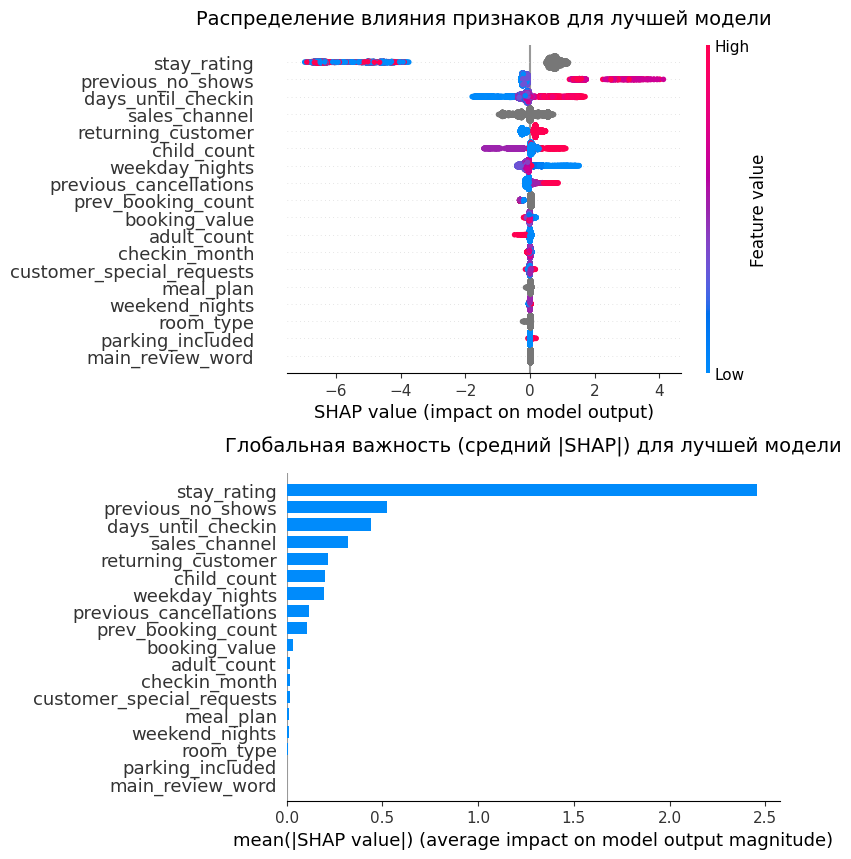

In [93]:
show_shap_analysis(best_model_calibrated.estimator.estimator, 'лучшей модели', X_val)

Анализ:

Наиболее важный признак по оценке модели: оценка клиента о прошлом посещении. Этот признак отражают лояльность клиента к сети отелей. Тут прослеживается отрицательная связь с таргетом: чем более лояльный клиент, тем меньше вероятно он отменит бронь.

Остальные признаки по важности сильно уступают.

Подтверждение прошлой брони - важный признак для модели: если ранее клиент подтверждал бронь своим заездом, то веротянее и дальше так будет.
Высокая важность у признака: кол-во дней до заезда. Это объясняется тем, что при длительном сроке до заезда высокая вероятность, что планы изменятся и придется отменять бронь.

Менее всего влияют на отмену брони: информация из отзывов, тип номера, наличие паркинга.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Этап 3: расчёт экономической эффективности модели

### Подготовка данных для расчета экономики


In [94]:
TARGET_CANCEL_SHARE = 0.10
MAX_OCCUPANCY_DECREASE = 8
TARGET_RELATIVE_IR = 50

y_pred = y_test_pred_final.copy()
y_pred_before = np.zeros_like(np.asarray(y_test), dtype=int)


def get_confusion_counts(y_true, y_pred):
    """Матрица ошибок в виде словаря"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}


def safe_relative_change(after, before):
    """Относительое изменение"""
    return (after - before) / before * 100

### Расчет показателей до и после внедрения модели


In [95]:
test_counts = get_confusion_counts(y_test, y_pred)

total_bookings = len(y_test)
total_cancellations = int(np.asarray(y_test).sum())
total_success = total_bookings - total_cancellations

ir_before = inc_rev_metric(y_test, y_pred_before)
ir_after = inc_rev_metric(y_test, y_pred)
incremental_revenue = ir_after - ir_before

cancel_share_before = total_cancellations / total_bookings
cancel_share_after = test_counts['fn'] / total_bookings

occupancy_before = total_success / total_bookings
occupancy_after = (total_success + test_counts['tp']) / total_bookings

business_metrics_df = pd.DataFrame(
    [
        {
            'period': 'до внедрения',
            'cancel_share': cancel_share_before * 100,
            'occupancy': occupancy_before * 100,
            'IR': ir_before,
        },
        {
            'period': 'после внедрения',
            'cancel_share': cancel_share_after * 100,
            'occupancy': occupancy_after * 100,
            'IR': ir_after,
        },
    ]
)

business_metrics_df[['cancel_share', 'occupancy']] = business_metrics_df[
    ['cancel_share', 'occupancy']
].round(2)
business_metrics_df['IR'] = business_metrics_df['IR'].round(0).astype('int64')

display(business_metrics_df)
display(pd.DataFrame([test_counts]))

,period,cancel_share,occupancy,IR
0,до внедрения,27.02,72.98,190597500
1,после внедрения,6.50,93.50,290054500


,tn,fp,fn,tp
0,4063,629,418,1319


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>
`occupancy_after = (total_success + test_counts['tp']) / total_bookings` — это (tn + tp + fp) / total. Но в контексте данной брони при tp и fp заселения не происходит, поскольку модель отменяет бронь. Нужно считать только реально занятые номера (TN), когда номер свободен и может быть снова забронирован — это не заселённый номер.
</font>

### Динамика показателей и достижение целевых уровней

In [96]:
cancel_share_dynamic = (cancel_share_before - cancel_share_after) / cancel_share_before * 100
occupancy_dynamic = (occupancy_before - occupancy_after) / occupancy_before * 100
relative_ir = safe_relative_change(ir_after, ir_before)

business_targets_df = pd.DataFrame(
    [
        {
            'metric': 'Доля отмен после внедрения',
            'value': cancel_share_after * 100,
            'target': '<= 10%',
            'target_reached': cancel_share_after <= TARGET_CANCEL_SHARE,
        },
        {
            'metric': 'Снижение загрузки',
            'value': occupancy_dynamic,
            'target': '<= 8%',
            'target_reached': occupancy_dynamic <= MAX_OCCUPANCY_DECREASE,
        },
        {
            'metric': 'Относительный IR',
            'value': relative_ir,
            'target': '>= 50%',
            'target_reached': relative_ir >= TARGET_RELATIVE_IR,
        },
    ]
)

business_targets_df['value'] = business_targets_df['value'].round(2)
business_targets_df['target_reached'] = business_targets_df['target_reached'].map({True: 'да', False: 'нет'})

display(business_targets_df)

print(f'Динамика доли отмен: {cancel_share_dynamic:.2f}%.')
print(f'Динамика загрузки: {occupancy_dynamic:.2f}%.')
print(f'Прирост IR: {incremental_revenue:,.0f}.')
print(f'Относительный IR: {relative_ir:.2f}%.')

,metric,value,target,target_reached
0,Доля отмен после внедрения,6.50,<= 10%,да
1,Снижение загрузки,-28.11,<= 8%,да
2,Относительный IR,52.18,>= 50%,да


Динамика доли отмен: 75.94%.
Динамика загрузки: -28.11%.
Прирост IR: 99,457,000.
Относительный IR: 52.18%.


### Выводы по экономической эффективности

In [97]:
cancel_target_reached = cancel_share_after <= TARGET_CANCEL_SHARE
occupancy_target_reached = occupancy_dynamic <= MAX_OCCUPANCY_DECREASE
relative_ir_target_reached = relative_ir >= TARGET_RELATIVE_IR
all_targets_reached = all([
    cancel_target_reached,
    occupancy_target_reached,
    relative_ir_target_reached,
])

print(
    'После внедрения модели доля необработанных отмен составляет '
    f'{cancel_share_after:.2%} против {cancel_share_before:.2%} до внедрения.'
)
print(
    'Загрузка изменилась с '
    f'{occupancy_before:.2%} до {occupancy_after:.2%}; '
    f'динамика по заданной формуле: {occupancy_dynamic:.2f}%.'
)
print(
    f'Финансовый результат до внедрения: {ir_before:,.0f}; '
    f'после внедрения: {ir_after:,.0f}; прирост: {incremental_revenue:,.0f}.'
)

if all_targets_reached:
    print('Все целевые бизнес-показатели достигнуты: модель можно рекомендовать к внедрению.')
else:
    print('Не все целевые бизнес-показатели достигнуты: перед внедрением нужно проверить стоимость ложных срабатываний и допустимый уровень овербукинга.')

После внедрения модели доля необработанных отмен составляет 6.50% против 27.02% до внедрения.
Загрузка изменилась с 72.98% до 93.50%; динамика по заданной формуле: -28.11%.
Финансовый результат до внедрения: 190,597,500; после внедрения: 290,054,500; прирост: 99,457,000.
Все целевые бизнес-показатели достигнуты: модель можно рекомендовать к внедрению.


## Этап 4: выводы по проекту

### Выводы о проделанной работе



**Подготовка данных**

Исходные данные загружены из двух таблиц: датасет с инфомрацией о бронировании и отзывах.
Первичный анализ при загрузке подтвердил корректность считываемых данных и соотвествие их описанию.
Исследовательский анализ выявил малую долю дубликатов (менее 0.1%), которые были удалены. 
Также были выявленые и исправлены опечатки в названии колонок. 
На основе текстовой информации из отзывов были сформированы новые признак: наиболее значимые по метрике TF-IDF слова, характеризующие отзывы.
Сформированы признак лояльности клиентов: кол-во предыдущих посещений. Добавлен признак сезонности: месяц заселения.
Сформирован итоговый датасет: без дублей, но с пропусками в признаках лояльности с долей 63%. Это объясняется тем, что малая доля клиентов пишет отзывы и оценивают свое пребывание в отеле.

**Моделирование**

Проведено обучение 2 базовых моделей градиентного бустинга: CatBoostClassifier и XGBClassifier. 
Базовые модели показали приемлемые метрики качества предсказаний (более 0.7 f1-macro и близкие показатели по IR) и отсутствие явного переобучения (малое отличие train и valid метрик). Это говорит о том, что модели применимы к поставленной задаче. В то же время базовые модели сущесвтенно хуже предсказывают малочисленный класс отмены броней. Возникает потребность в оптимизации гиперпараметров.

Для улучшения качества предсказаний и, в конечном итоге, для увеличения финансовых показателей модели, была проведена оптимизация гиперпарметров по показателю IR. По результатам оптимизации была выявляна лучшая модель: CatBoostClassifier с подобранными гиперпараметрами. Проведена калибровка лучшей модели и определен оптимальный по финансовым показателям порог по вероятности для принятия решения: прогнозируем отмену брони или нет. 

**Оценка метрик**

Анализ матрицы классификации позволяет понять, что оптимизированная модель обучена избегать сценариев: бронь отменилась и номер по итогу не сдан. Это объясняется тем, что такой промах наиболее дорог по финансовым потерям. Таким образом, модель склонна стимулировать овербукинг.
Модель показала стабильное качество на validate и test выборках и рекомендована к внедрению, поскольку все требования по ключевым метрикам выполнены.


**Анализа важности факторов**

Анализ важности прихнаков показал, что рейтинг, который поставил клиент по результатам предыдущего визита наиболее важный фактор для прогноза  отмены брони. Если клиент высоко оценивает сервис, то вероятность отмены брони минимальна.



### Выводы по анализу эффективности модели

Разработанная модель позволяет принимать обоснованные решения по прогнозированию отмены броней в отеле.
Модель обучена на исторических данных о бронях клиентов и информации из отзывов.

Говоря об экономической эффективности разработанной модели:

После внедрения модели доля необработанных отмен составляет 6.50% против 27.02% до внедрения.
Загрузка изменилась с 72.98% до 93.50%;
Финансовый результат до внедрения: 190,597,500; после внедрения: 290,054,500; прирост: 99,457,000.
Все целевые бизнес-показатели достигнуты: модель рекомендована к внедрению.

Основными признаками, позволяющими прогнозировать отмену брони являются: рейтинг прошлого посещения отеля (высокий рейтинг - клент скорее всего не отменит бронь), информация о прошлых подтвержденных визитах (уже подтверждал - скорее всего и в этот раз подтвредит), время до заезда (чем больше времени, тем вероятней отмена).

*Рекомендации для бизнеса*:
- внедрение модели позволит существенно повысить заполняемость номеров в отеле и прибыльность компании
- модель склонна к овербукингу - часто прогнозирует отмену, хотя клиент заезжает. Для избежания репутационных потерь, необходимо ограничить сверху перепроданность номеров. 
- информация о рейтинге предыдущего посещения крайне важная. Стоит простимулировать клиентов давать обратную связь, чтобы потом лучше прогнозировать отмены. 
- большой срок перед заездом увеличивает вероятность отмены. Рекомендуется продумать доп. условия для такого рода случаев. Допустим, гибкость при переносе брони на другой день.   

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'> Арсений, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>